# ORR EqV2 trajectory screening and adsorption-site analysis

This notebook screens **every ASE `.traj` file** stored in each adsorbate-specific calculation folder, independently of the trajectory filename.

## Required input layout

```text
ORR_EqV2_Relaxation_Trajectories/
├── mp-1418_100_O/
│   ├── 0.traj
│   ├── 1.traj
│   └── ...
├── mp-1008349_111_O/
│   ├── config_0.traj
│   ├── config_1.traj
│   └── ...
├── mp-1418_100_OH/
│   └── any_valid_name.traj
└── mp-1418_100_OOH/
    └── another_name.traj
```

Filename style is **not** a screening criterion. Files such as `0.traj`, `config_0.traj`, or any other `*.traj` filename are all read and screened identically. Corresponding `.log` files are ignored because they are not ASE trajectory files.

## Screening criteria

Each `.traj` file is read completely, checked for at least two frames, validated for adsorbate stoichiometry, screened with FairChem `DetectTrajAnomaly`, required to satisfy \(F_{\max}<0.05\) eV Å\(^{-1}\), and assigned a final adsorption-site motif.

Final total energies are compared only within the same slab–adsorbate folder, where composition is fixed. Filename parsing is used only to create a readable label and natural ordering; it never determines inclusion or exclusion.


## Publication-oriented naming

Recommended raw-data directory:

```text
ORR_EqV2_Relaxation_Trajectories
```

Recommended analysis directory:

```text
ORR_EqV2_Adsorption_Site_Analysis
```

Primary processed table:

```text
orr_eqv2_unique_adsorption_site_minima.csv
```

In [1]:
from pathlib import Path
from importlib.metadata import PackageNotFoundError, version
import itertools
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ase
import ase.io as aseio
from ase.data import atomic_numbers, covalent_radii
from IPython.display import display
from tqdm.auto import tqdm

try:
    from fairchem.data.oc.utils import DetectTrajAnomaly
except ImportError as exc:
    raise ImportError(
        "A compatible fairchem-core installation is required. "
        "Use the same FairChem environment used for the EqV2 relaxations."
    ) from exc


def installed_version(distribution_name):
    """Return an installed package version without interrupting the notebook."""
    try:
        return version(distribution_name)
    except PackageNotFoundError:
        return "not found"


print("Software environment")
print(f"  NumPy:         {np.__version__}")
print(f"  pandas:        {pd.__version__}")
print(f"  ASE:           {ase.__version__}")
print(f"  fairchem-core: {installed_version('fairchem-core')}")

Software environment
  NumPy:         1.26.4
  pandas:        2.3.3
  ASE:           3.28.0
  fairchem-core: 1.2.0


In [2]:
# Input and output directories
DATA_ROOT = Path("ORR_EqV2_Relaxation_Trajectories")
OUTPUT_DIR = Path("ORR_EqV2_Adsorption_Site_Analysis")

# Screening settings
MAX_FORCE_THR = 0.05  # eV/Å
ADSORBATES_TO_PROCESS = {"O", "OH", "OOH"}

# Adsorption-site detection parameters
LOCAL_XY_RADIUS = 4.5
LOCAL_LAYER_TOL = 1.8
TOP_XY_TOL = 0.45
BRIDGE_DIST_TOL = 0.65
MAX_BRIDGE_LEN = 4.4
HOLLOW_EDGE_MAX = 4.7
BOND_BUFFER = 0.65
MAX_BOND_DIST = 3.0
DIST_TIE_TOL = 0.22

# Publication-oriented output tables
OUT_ALL_RECORDS = OUTPUT_DIR / "orr_eqv2_all_trajectory_quality_control.csv"
OUT_VALIDATED = OUTPUT_DIR / "orr_eqv2_validated_relaxation_trajectories.csv"
OUT_UNIQUE_MINIMA = OUTPUT_DIR / "orr_eqv2_unique_adsorption_site_minima.csv"
OUT_FAMILY_MINIMA = OUTPUT_DIR / "orr_eqv2_adsorption_site_family_minima.csv"
OUT_GLOBAL_MINIMA = OUTPUT_DIR / "orr_eqv2_global_minimum_configuration_per_system.csv"
OUT_SYSTEM_SUMMARY = OUTPUT_DIR / "orr_eqv2_quality_control_summary_by_system.csv"

print(f"Input directory:  {DATA_ROOT.resolve()}")
print(f"Output directory: {OUTPUT_DIR.resolve()}")

Input directory:  /Users/ismailcanoguz/Downloads/ORR_EqV2_Relaxation_Trajectories
Output directory: /Users/ismailcanoguz/Downloads/ORR_EqV2_Adsorption_Site_Analysis


## 1. System-folder parsing and complete `.traj` discovery

Only top-level folders matching `mp-<id>_<facet>_<adsorbate>` are treated as slab–adsorbate systems. Inside each matched folder, **all files with the `.traj` extension are processed**. No assumption is made about whether the filename is numeric, begins with `config_`, or uses another label.


In [3]:
SYSTEM_FOLDER_PATTERN = re.compile(
    r"^(?P<material_id>mp-\d+)_(?P<facet>\d+)_(?P<adsorbate>OOH|OH|O)$",
    flags=re.IGNORECASE,
)


def parse_system_folder(folder):
    """Parse a system folder such as mp-1418_100_O."""
    match = SYSTEM_FOLDER_PATTERN.fullmatch(folder.name)
    if match is None:
        return None

    material_id = match.group("material_id").lower()
    facet = match.group("facet")
    adsorbate = match.group("adsorbate").upper()

    return {
        "system_id": folder.name,
        "material_id": material_id,
        "facet": facet,
        "surface_id": f"{material_id}_{facet}",
        "adsorbate": adsorbate,
    }


def natural_sort_key(value):
    """
    Return a deterministic natural-sort key.

    Examples
    --------
    2.traj is ordered before 10.traj.
    config_2.traj is ordered before config_10.traj.
    Arbitrary string filenames remain supported.
    """
    name = value.name if isinstance(value, Path) else str(value)
    parts = re.split(r"(\d+)", name.casefold())
    return tuple(
        (0, int(part)) if part.isdigit() else (1, part)
        for part in parts
        if part != ""
    )


def trajectory_identity(path, trajectory_order):
    """
    Create labels for a trajectory without filtering by filename.

    configuration_index is extracted from the last integer in the stem when
    available. It is metadata only. trajectory_order is always present and
    follows natural filename ordering within the folder.
    """
    numeric_tokens = re.findall(r"\d+", path.stem)
    configuration_index = (
        int(numeric_tokens[-1]) if numeric_tokens else None
    )

    return {
        "trajectory_label": path.stem,
        "configuration_index": configuration_index,
        "trajectory_order": int(trajectory_order),
        "trajectory_filename": path.name,
    }


def discover_system_folders(data_root):
    """Return matched and unmatched top-level directories."""
    all_directories = sorted(
        (path for path in data_root.iterdir() if path.is_dir()),
        key=lambda path: natural_sort_key(path.name),
    )

    matched = []
    unmatched = []

    for folder in all_directories:
        info = parse_system_folder(folder)
        if info is None:
            unmatched.append(folder)
        else:
            matched.append((folder, info))

    return matched, unmatched


def discover_all_trajectories(system_folder):
    """
    Return every .traj file in deterministic natural order.

    No .traj file is rejected based on its stem. The extension match is
    case-insensitive to also cover .TRAJ when present.
    """
    trajectories = [
        path
        for path in system_folder.iterdir()
        if path.is_file() and path.suffix.casefold() == ".traj"
    ]
    return sorted(trajectories, key=natural_sort_key)


def relative_trajectory_path(path, data_root):
    """Return a stable POSIX path relative to the dataset root."""
    return path.relative_to(data_root).as_posix()


In [4]:
# Parser and discovery tests for the filename styles present in the dataset.
assert parse_system_folder(Path("mp-1418_100_O")) == {
    "system_id": "mp-1418_100_O",
    "material_id": "mp-1418",
    "facet": "100",
    "surface_id": "mp-1418_100",
    "adsorbate": "O",
}
assert parse_system_folder(Path("mp-1418_100_OH"))["adsorbate"] == "OH"
assert parse_system_folder(Path("mp-1418_100_OOH"))["adsorbate"] == "OOH"

_test_names = [
    Path("10.traj"),
    Path("2.traj"),
    Path("config_10.traj"),
    Path("config_2.traj"),
    Path("final_candidate.traj"),
]
_test_sorted = [path.name for path in sorted(_test_names, key=natural_sort_key)]
assert _test_sorted.index("2.traj") < _test_sorted.index("10.traj")
assert _test_sorted.index("config_2.traj") < _test_sorted.index("config_10.traj")

assert trajectory_identity(Path("0.traj"), 0)["configuration_index"] == 0
assert trajectory_identity(Path("config_13.traj"), 0)["configuration_index"] == 13
assert trajectory_identity(Path("relaxed_bridge.traj"), 0)["configuration_index"] is None

print("System-folder parser and all-.traj discovery tests passed.")


System-folder parser and all-.traj discovery tests passed.


In [5]:
if not DATA_ROOT.exists():
    raise FileNotFoundError(
        f"Input directory not found: {DATA_ROOT.resolve()}\n"
        "Rename the raw-data folder to "
        "'ORR_EqV2_Relaxation_Trajectories' "
        "or update DATA_ROOT above."
    )

matched_systems, unmatched_directories = discover_system_folders(DATA_ROOT)

if not matched_systems:
    raise RuntimeError(
        "No folders matched the required pattern "
        "'mp-<id>_<facet>_<O|OH|OOH>'."
    )

inventory_rows = []
filename_style_rows = []
expected_relative_traj_paths = []

for folder, info in matched_systems:
    trajectories = discover_all_trajectories(folder)

    identities = [
        trajectory_identity(path, order)
        for order, path in enumerate(trajectories)
    ]

    inventory_rows.append(
        {
            **info,
            "system_directory": str(folder),
            "n_traj_files": len(trajectories),
            "first_trajectory_filename": (
                trajectories[0].name if trajectories else None
            ),
            "last_trajectory_filename": (
                trajectories[-1].name if trajectories else None
            ),
        }
    )

    for path, identity in zip(trajectories, identities):
        expected_relative_traj_paths.append(
            relative_trajectory_path(path, DATA_ROOT)
        )

        if path.stem.isdigit():
            style = "integer"
        elif re.fullmatch(r"config_\d+", path.stem, flags=re.IGNORECASE):
            style = "config_integer"
        else:
            style = "other_string"

        filename_style_rows.append(
            {
                "system_id": info["system_id"],
                "trajectory_filename": path.name,
                "trajectory_label": identity["trajectory_label"],
                "configuration_index": identity["configuration_index"],
                "trajectory_order": identity["trajectory_order"],
                "filename_style": style,
            }
        )


df_inventory = pd.DataFrame(inventory_rows)
df_filename_styles = pd.DataFrame(filename_style_rows)
expected_relative_traj_paths = sorted(set(expected_relative_traj_paths))

if len(expected_relative_traj_paths) != int(df_inventory["n_traj_files"].sum()):
    raise RuntimeError(
        "Duplicate or inconsistent trajectory paths were found during preflight."
    )

print("Preflight scan")
print(f"  Matched slab–adsorbate folders: {len(matched_systems):,}")
print(f"  All .traj files:                {len(expected_relative_traj_paths):,}")
print(f"  Unmatched directories:          {len(unmatched_directories):,}")

display(df_inventory.head(12))

style_summary = (
    df_filename_styles["filename_style"]
    .value_counts(dropna=False)
    .rename_axis("filename_style")
    .reset_index(name="n_traj_files")
)
print("\nFilename styles (all are processed):")
display(style_summary)

sample_folder, sample_info = matched_systems[0]
sample_trajs = discover_all_trajectories(sample_folder)
print(f"\nExample folder: {sample_info['system_id']}")
print("First trajectories in natural order:")
for order, path in enumerate(sample_trajs[:10]):
    identity = trajectory_identity(path, order)
    print(
        f"  order={identity['trajectory_order']:>3d}  "
        f"label={identity['trajectory_label']:<20s}  file={path.name}"
    )

if unmatched_directories:
    print("\nUnmatched directories were not processed:")
    for path in unmatched_directories[:20]:
        print(f"  {path.name}")


Preflight scan
  Matched slab–adsorbate folders: 1,668
  All .traj files:                72,391
  Unmatched directories:          0


,system_id,material_id,facet,surface_id,adsorbate,system_directory,n_traj_files,first_trajectory_filename,last_trajectory_filename
0,mp-126_111_O,mp-126,111,mp-126_111,O,ORR_EqV2_Relaxation_Trajectories/mp-126_111_O,54,config_0.traj,config_53.traj
1,mp-126_111_OH,mp-126,111,mp-126_111,OH,ORR_EqV2_Relaxation_Trajectories/mp-126_111_OH,54,config_0.traj,config_53.traj
2,mp-126_111_OOH,mp-126,111,mp-126_111,OOH,ORR_EqV2_Relaxation_Trajectories/mp-126_111_OOH,34,config_0.traj,config_33.traj
3,mp-265_100_O,mp-265,100,mp-265_100,O,ORR_EqV2_Relaxation_Trajectories/mp-265_100_O,30,0.traj,29.traj
4,mp-265_100_OH,mp-265,100,mp-265_100,OH,ORR_EqV2_Relaxation_Trajectories/mp-265_100_OH,30,0.traj,29.traj
5,mp-265_100_OOH,mp-265,100,mp-265_100,OOH,ORR_EqV2_Relaxation_Trajectories/mp-265_100_OOH,30,0.traj,29.traj
6,mp-265_110_O,mp-265,110,mp-265_110,O,ORR_EqV2_Relaxation_Trajectories/mp-265_110_O,31,0.traj,30.traj
7,mp-265_110_OH,mp-265,110,mp-265_110,OH,ORR_EqV2_Relaxation_Trajectories/mp-265_110_OH,31,0.traj,30.traj
8,mp-265_110_OOH,mp-265,110,mp-265_110,OOH,ORR_EqV2_Relaxation_Trajectories/mp-265_110_OOH,31,0.traj,30.traj
9,mp-265_111_O,mp-265,111,mp-265_111,O,ORR_EqV2_Relaxation_Trajectories/mp-265_111_O,29,0.traj,28.traj



Filename styles (all are processed):


,filename_style,n_traj_files
0,integer,66058
1,config_integer,6333



Example folder: mp-126_111_O
First trajectories in natural order:
  order=  0  label=config_0              file=config_0.traj
  order=  1  label=config_1              file=config_1.traj
  order=  2  label=config_2              file=config_2.traj
  order=  3  label=config_3              file=config_3.traj
  order=  4  label=config_4              file=config_4.traj
  order=  5  label=config_5              file=config_5.traj
  order=  6  label=config_6              file=config_6.traj
  order=  7  label=config_7              file=config_7.traj
  order=  8  label=config_8              file=config_8.traj
  order=  9  label=config_9              file=config_9.traj


## 2. ASE trajectory, energy, force, and composition helpers

In [6]:
EXPECTED_ADSORBATE_COUNTS = {
    "O": {"O": 1, "H": 0},
    "OH": {"O": 1, "H": 1},
    "OOH": {"O": 2, "H": 1},
}


def read_traj_all(path):
    """Read every frame from an ASE .traj file."""
    frames = aseio.read(str(path), index=":")
    if isinstance(frames, list):
        return frames
    return [frames]


def get_energy(atoms):
    """Retrieve a stored total energy from an ASE Atoms object."""
    try:
        return float(atoms.get_potential_energy())
    except Exception:
        pass

    if atoms.calc is not None and hasattr(atoms.calc, "results"):
        for key in ("energy", "free_energy"):
            if key in atoms.calc.results:
                return float(atoms.calc.results[key])

    for key in ("energy", "free_energy", "potential_energy"):
        if key in atoms.info:
            return float(atoms.info[key])

    return np.nan


def get_forces(atoms):
    """Retrieve stored forces from an ASE Atoms object."""
    try:
        return np.asarray(atoms.get_forces(), dtype=float)
    except Exception:
        pass

    if atoms.calc is not None and hasattr(atoms.calc, "results"):
        if "forces" in atoms.calc.results:
            return np.asarray(atoms.calc.results["forces"], dtype=float)

    if "forces" in atoms.arrays:
        return np.asarray(atoms.arrays["forces"], dtype=float)

    return None


def get_fmax(atoms):
    """Return the maximum atomic force norm in eV/Å."""
    forces = get_forces(atoms)
    if forces is None or len(forces) == 0:
        return np.nan
    return float(np.linalg.norm(forces, axis=1).max())


def composition_signature(atoms):
    """Return atom count and Hill chemical formula."""
    return len(atoms), atoms.get_chemical_formula(mode="hill")


def check_expected_adsorbate_stoichiometry(atoms, adsorbate):
    """
    Validate O/H counts for metallic alloy slabs containing O*, OH*, or OOH*.
    """
    symbols = atoms.get_chemical_symbols()
    observed = {
        "O": symbols.count("O"),
        "H": symbols.count("H"),
    }
    expected = EXPECTED_ADSORBATE_COUNTS[adsorbate]
    return observed == expected, observed, expected

## 3. FairChem anomaly detection

The first and final frames of each trajectory are passed to `DetectTrajAnomaly`. Detector failures are written to the quality-control table as rejected records.

In [7]:
def get_adsorbate_indices(atoms, adsorbate):
    """
    For these alloy slabs, O/H atoms belong to adsorbates.
    O*   -> O
    OH*  -> O + H
    OOH* -> O + O + H
    """
    symbols = atoms.get_chemical_symbols()
    adsorbate = str(adsorbate).upper().replace("*", "")

    if adsorbate == "O":
        return [i for i, s in enumerate(symbols) if s == "O"]

    if adsorbate in {"OH", "OOH"}:
        return [i for i, s in enumerate(symbols) if s in {"O", "H"}]

    return [i for i, s in enumerate(symbols) if s in {"O", "H"}]


def enforce_adsorbate_tags(atoms, adsorbate):
    """
    FairChem DetectTrajAnomaly expects atom tags:
      tag 2 = adsorbate
      tag 1 = slab/surface
    This function makes the tags explicit and consistent.
    """
    atoms = atoms.copy()
    ads_idx = set(get_adsorbate_indices(atoms, adsorbate))

    tags = np.ones(len(atoms), dtype=int)
    for i in ads_idx:
        tags[i] = 2

    atoms.set_tags(tags)
    return atoms, tags


def run_fairchem_anomaly_detection(traj, adsorbate):
    """
    Use the actual FairChem anomaly detector.
    Treat detector failure as bad, same as your previous code.
    """
    initial, tags0 = enforce_adsorbate_tags(traj[0], adsorbate)
    final, _ = enforce_adsorbate_tags(traj[-1], adsorbate)

    det = DetectTrajAnomaly(initial, final, tags0)

    f_diss = bool(det.is_adsorbate_dissociated())
    f_des  = bool(det.is_adsorbate_desorbed())
    f_surf = bool(det.has_surface_changed())
    f_int  = bool(det.is_adsorbate_intercalated())

    has_anom = any([f_diss, f_des, f_surf, f_int])

    reason = []
    if f_diss:
        reason.append("adsorbate_dissociated")
    if f_des:
        reason.append("adsorbate_desorbed")
    if f_surf:
        reason.append("surface_changed")
    if f_int:
        reason.append("adsorbate_intercalated")

    return has_anom, ";".join(reason) if reason else "ok", {
        "anom_ads_dissociated": f_diss,
        "anom_ads_desorbed": f_des,
        "anom_surface_changed": f_surf,
        "anom_ads_intercalated": f_int,
    }

## 4. Periodic surface geometry and adsorption-site assignment

In [8]:
def mic_vectors_from_anchor(atoms, anchor_pos, positions, wrap_xy=True):
    """
    Minimum-image vectors from anchor_pos to positions.
    ASE row-vector convention: cart = frac @ cell.
    Only x/y are wrapped; z is not wrapped for slabs.
    """
    cell = np.asarray(atoms.cell.array, dtype=float)
    inv_cell = np.linalg.inv(cell)

    f0 = anchor_pos @ inv_cell
    f = positions @ inv_cell
    df = f - f0

    if wrap_xy:
        df[:, 0] -= np.round(df[:, 0])
        df[:, 1] -= np.round(df[:, 1])

    return df @ cell


def point_segment_distance_2d(p, a, b):
    ab = b - a
    denom = float(np.dot(ab, ab))
    if denom < 1e-12:
        return float(np.linalg.norm(p - a)), 0.0

    t = float(np.dot(p - a, ab) / denom)
    t_clip = max(0.0, min(1.0, t))
    closest = a + t_clip * ab
    return float(np.linalg.norm(p - closest)), t_clip


def point_in_triangle_2d(p, a, b, c, eps=1e-8):
    v0 = c - a
    v1 = b - a
    v2 = p - a

    den = v0[0] * v1[1] - v1[0] * v0[1]
    if abs(den) < 1e-12:
        return False

    u = (v2[0] * v1[1] - v1[0] * v2[1]) / den
    v = (v0[0] * v2[1] - v2[0] * v0[1]) / den

    return (u >= -eps) and (v >= -eps) and (u + v <= 1.0 + eps)


def site_type_from_n(n):
    if n == 1:
        return "top"
    if n == 2:
        return "bridge"
    if n == 3:
        return "3-fold"
    if n == 4:
        return "4-fold"
    if n <= 0:
        return "unknown"
    return f"{n}-fold"


def canonical_neighbor_string(symbols):
    return "-".join(sorted(symbols))

In [9]:
def choose_anchor_O(atoms, adsorbate, ads_idx, surf_idx):
    """
    Anchor atom:
      O*   -> O
      OH*  -> O
      OOH* -> O closest to slab
    """
    symbols = atoms.get_chemical_symbols()
    positions = atoms.get_positions()

    o_ads = [i for i in ads_idx if symbols[i] == "O"]
    if not o_ads:
        return None

    if len(o_ads) == 1:
        return o_ads[0]

    slab_pos = positions[surf_idx]

    best_i = None
    best_d = np.inf

    for oi in o_ads:
        vecs = mic_vectors_from_anchor(atoms, positions[oi], slab_pos)
        dmin = float(np.linalg.norm(vecs, axis=1).min())
        if dmin < best_d:
            best_i = oi
            best_d = dmin

    return best_i


def build_site_result(selected, reason):
    selected = sorted(selected, key=lambda x: x["idx"])

    syms = [x["sym"] for x in selected]
    idxs = [int(x["idx"]) for x in selected]
    dists = [float(x["r3d"]) for x in selected]

    site_type = site_type_from_n(len(selected))
    neighbor_string = canonical_neighbor_string(syms)

    return {
        "site_type": site_type,
        "nearest_symbols": syms,
        "neighbor_string": neighbor_string,
        "neighbor_indices": "-".join(map(str, idxs)),
        "neighbor_distances_A": ";".join(f"{d:.4f}" for d in dists),
        "site_family": f"{site_type}__{neighbor_string}",
        "site_reason": reason,
    }


def detect_ads_site_buckled(atoms, adsorbate):
    """
    Improved site detector:
      - chooses O anchor
      - builds local buckled top-layer candidate list
      - detects top / bridge / hollow from x-y projection
      - uses covalent-distance fallback only if projection fails
    """
    atoms, tags = enforce_adsorbate_tags(atoms, adsorbate)

    symbols = atoms.get_chemical_symbols()
    positions = atoms.get_positions()

    ads_idx = np.where(tags == 2)[0].tolist()
    surf_idx = np.where(tags == 1)[0].tolist()

    anchor = choose_anchor_O(atoms, adsorbate, ads_idx, surf_idx)
    if anchor is None:
        return {
            "site_type": "unknown",
            "nearest_symbols": [],
            "neighbor_string": None,
            "neighbor_indices": None,
            "neighbor_distances_A": None,
            "site_family": "unknown",
            "site_reason": "no_anchor_O",
        }

    anchor_pos = positions[anchor]
    surf_pos = positions[surf_idx]

    vecs = mic_vectors_from_anchor(atoms, anchor_pos, surf_pos)
    r3d = np.linalg.norm(vecs, axis=1)
    rxy = np.linalg.norm(vecs[:, :2], axis=1)
    dz = vecs[:, 2]

    surf_z = positions[surf_idx, 2]
    median_z = float(np.median(surf_z))
    top_side = anchor_pos[2] >= median_z

    # Select local surface atoms from the same side of the slab.
    if top_side:
        same_side = dz < 0.7
        local = same_side & (rxy <= LOCAL_XY_RADIUS)
        if not np.any(local):
            local = same_side
        z_extreme = float(np.max(surf_z[local]))
        layer_mask = local & (surf_z >= z_extreme - LOCAL_LAYER_TOL)
    else:
        same_side = dz > -0.7
        local = same_side & (rxy <= LOCAL_XY_RADIUS)
        if not np.any(local):
            local = same_side
        z_extreme = float(np.min(surf_z[local]))
        layer_mask = local & (surf_z <= z_extreme + LOCAL_LAYER_TOL)

    cand_local_ids = np.where(layer_mask)[0]

    if len(cand_local_ids) == 0:
        cand_local_ids = np.argsort(r3d)[:8]

    cand_local_ids = sorted(cand_local_ids, key=lambda k: (rxy[k], r3d[k]))[:14]

    cand = []
    for k in cand_local_ids:
        gi = surf_idx[k]
        cand.append({
            "k": int(k),
            "idx": int(gi),
            "sym": symbols[gi],
            "xy": vecs[k, :2],
            "rxy": float(rxy[k]),
            "r3d": float(r3d[k]),
            "dz": float(dz[k]),
            "z": float(positions[gi, 2]),
        })

    p0 = np.zeros(2)

    # 1. Clear projected top site
    nearest_proj = min(cand, key=lambda x: x["rxy"])
    if nearest_proj["rxy"] <= TOP_XY_TOL:
        return build_site_result([nearest_proj], "projection_top")

    # 2. Bridge site from projection onto surface-atom pair
    bridge_candidates = []

    for a, b in itertools.combinations(cand, 2):
        pair_len = float(np.linalg.norm(a["xy"] - b["xy"]))
        if pair_len > MAX_BRIDGE_LEN:
            continue

        dseg, t = point_segment_distance_2d(p0, a["xy"], b["xy"])

        if dseg <= BRIDGE_DIST_TOL and -0.10 <= t <= 1.10:
            endpoint_penalty = abs(t - 0.5)
            dist_penalty = 0.03 * (a["r3d"] + b["r3d"])
            score = dseg + 0.20 * endpoint_penalty + dist_penalty
            bridge_candidates.append((score, dseg, t, a, b))

    if bridge_candidates:
        bridge_candidates.sort(key=lambda x: x[0])
        _, _, _, a, b = bridge_candidates[0]
        return build_site_result([a, b], "projection_bridge")

    # 3. Threefold hollow site from projected triangle
    hollow_candidates = []

    for tri in itertools.combinations(cand, 3):
        a, b, c = tri

        edges = [
            np.linalg.norm(a["xy"] - b["xy"]),
            np.linalg.norm(a["xy"] - c["xy"]),
            np.linalg.norm(b["xy"] - c["xy"]),
        ]

        if max(edges) > HOLLOW_EDGE_MAX:
            continue

        if point_in_triangle_2d(p0, a["xy"], b["xy"], c["xy"]):
            centroid = (a["xy"] + b["xy"] + c["xy"]) / 3.0
            score = float(np.linalg.norm(centroid)) + 0.02 * (
                a["r3d"] + b["r3d"] + c["r3d"]
            )
            hollow_candidates.append((score, a, b, c))

    if hollow_candidates:
        hollow_candidates.sort(key=lambda x: x[0])
        _, a, b, c = hollow_candidates[0]
        return build_site_result([a, b, c], "projection_hollow")

    # 4. Fallback: covalent-radius normalized distances
    anchor_sym = symbols[anchor]
    r_anchor = covalent_radii[atomic_numbers[anchor_sym]]

    scored = []
    for c in cand:
        r_surf = covalent_radii[atomic_numbers[c["sym"]]]
        rcov = r_anchor + r_surf
        norm = c["r3d"] / rcov if rcov > 0 else c["r3d"]
        bonded = (c["r3d"] <= rcov + BOND_BUFFER) or (c["r3d"] <= MAX_BOND_DIST)
        scored.append((norm, bonded, c))

    bonded_scored = [x for x in scored if x[1]]

    if bonded_scored:
        min_norm = min(x[0] for x in bonded_scored)
        selected = [x[2] for x in bonded_scored if x[0] <= min_norm + DIST_TIE_TOL]
        selected = sorted(selected, key=lambda x: x["r3d"])[:4]
        return build_site_result(selected, "bond_distance_fallback")

    return build_site_result([nearest_proj], "nearest_projection_fallback")

## 5. Screen every `.traj` file

The scanner processes every `.traj` file discovered in every matched slab–adsorbate folder. Numeric names, `config_<n>` names, and arbitrary string names follow the same scientific screening path. No bare-slab trajectory is searched for or required.


In [10]:
def make_system_summary(info, folder, n_traj_files):
    """Initialize per-system quality-control counters."""
    return {
        **info,
        "system_directory": str(folder),
        "n_traj_files": n_traj_files,
        "n_validated": 0,
        "n_unreadable": 0,
        "n_too_short": 0,
        "n_frame_composition_changed": 0,
        "n_adsorbate_stoichiometry_failed": 0,
        "n_detector_failed": 0,
        "n_anomalous": 0,
        "n_adsorbate_dissociated": 0,
        "n_adsorbate_desorbed": 0,
        "n_surface_changed": 0,
        "n_adsorbate_intercalated": 0,
        "n_energy_failed": 0,
        "n_force_failed": 0,
        "n_force_threshold_failed": 0,
        "n_site_assignment_failed": 0,
    }


def rejected_record(base, reason, **kwargs):
    """Create a standardized rejected trajectory record."""
    record = dict(base)
    record.update(
        validation_status="rejected",
        rejection_reason=reason,
        anomaly_detected=kwargs.pop("anomaly_detected", False),
        **kwargs,
    )
    return record


def screen_all_trajectories(data_root):
    """Screen every .traj file in every matched system folder."""
    all_records = []
    validated_records = []
    system_summaries = []

    matched_systems, _ = discover_system_folders(data_root)

    for folder, info in tqdm(
        matched_systems,
        desc="Screening slab–adsorbate folders",
    ):
        trajectories = discover_all_trajectories(folder)

        summary = make_system_summary(
            info=info,
            folder=folder,
            n_traj_files=len(trajectories),
        )

        for trajectory_order, traj_path in enumerate(trajectories):
            identity = trajectory_identity(traj_path, trajectory_order)

            base = {
                **info,
                **identity,
                "trajectory_relative_path": relative_trajectory_path(
                    traj_path,
                    data_root,
                ),
                "trajectory_file": str(traj_path),
            }

            # 1. Read the complete ASE trajectory.
            try:
                trajectory = read_traj_all(traj_path)
            except Exception as exc:
                summary["n_unreadable"] += 1
                all_records.append(
                    rejected_record(
                        base,
                        f"unreadable_trajectory:{type(exc).__name__}:{exc}",
                    )
                )
                continue

            n_frames = len(trajectory)

            # 2. Require at least an initial and a final frame.
            if n_frames < 2:
                summary["n_too_short"] += 1
                all_records.append(
                    rejected_record(
                        base,
                        "trajectory_has_fewer_than_two_frames",
                        n_frames=n_frames,
                    )
                )
                continue

            initial = trajectory[0]
            final = trajectory[-1]

            initial_n_atoms, initial_formula = composition_signature(initial)
            final_n_atoms, final_formula = composition_signature(final)

            # 3. Ensure composition did not change across the trajectory.
            if (
                initial_n_atoms != final_n_atoms
                or initial_formula != final_formula
            ):
                summary["n_frame_composition_changed"] += 1
                all_records.append(
                    rejected_record(
                        base,
                        "initial_final_composition_mismatch",
                        n_frames=n_frames,
                        initial_n_atoms=initial_n_atoms,
                        final_n_atoms=final_n_atoms,
                        initial_formula=initial_formula,
                        final_formula=final_formula,
                    )
                )
                continue

            # 4. Check the adsorbate identity encoded by the parent folder.
            stoich_ok, observed_counts, expected_counts = (
                check_expected_adsorbate_stoichiometry(
                    final,
                    info["adsorbate"],
                )
            )

            if not stoich_ok:
                summary["n_adsorbate_stoichiometry_failed"] += 1
                all_records.append(
                    rejected_record(
                        base,
                        "unexpected_O_H_stoichiometry",
                        n_frames=n_frames,
                        n_atoms=final_n_atoms,
                        chemical_formula=final_formula,
                        observed_O_atoms=observed_counts["O"],
                        observed_H_atoms=observed_counts["H"],
                        expected_O_atoms=expected_counts["O"],
                        expected_H_atoms=expected_counts["H"],
                    )
                )
                continue

            # 5. Run FairChem anomaly detection.
            try:
                has_anomaly, anomaly_reason, anomaly_flags = (
                    run_fairchem_anomaly_detection(
                        trajectory,
                        info["adsorbate"],
                    )
                )
            except Exception as exc:
                summary["n_detector_failed"] += 1
                all_records.append(
                    rejected_record(
                        base,
                        f"fairchem_detector_failed:{type(exc).__name__}:{exc}",
                        anomaly_detected=True,
                        n_frames=n_frames,
                        n_atoms=final_n_atoms,
                        chemical_formula=final_formula,
                    )
                )
                continue

            if has_anomaly:
                summary["n_anomalous"] += 1
                summary["n_adsorbate_dissociated"] += int(
                    anomaly_flags["anom_ads_dissociated"]
                )
                summary["n_adsorbate_desorbed"] += int(
                    anomaly_flags["anom_ads_desorbed"]
                )
                summary["n_surface_changed"] += int(
                    anomaly_flags["anom_surface_changed"]
                )
                summary["n_adsorbate_intercalated"] += int(
                    anomaly_flags["anom_ads_intercalated"]
                )

                all_records.append(
                    rejected_record(
                        base,
                        anomaly_reason,
                        anomaly_detected=True,
                        n_frames=n_frames,
                        n_atoms=final_n_atoms,
                        chemical_formula=final_formula,
                        **anomaly_flags,
                    )
                )
                continue

            # 6. Retrieve final total energy.
            try:
                final_energy = get_energy(final)
                if not np.isfinite(final_energy):
                    raise ValueError("non-finite final energy")
            except Exception as exc:
                summary["n_energy_failed"] += 1
                all_records.append(
                    rejected_record(
                        base,
                        f"final_energy_read_failed:{type(exc).__name__}:{exc}",
                        n_frames=n_frames,
                        n_atoms=final_n_atoms,
                        chemical_formula=final_formula,
                    )
                )
                continue

            # 7. Retrieve final forces and apply convergence threshold.
            try:
                final_fmax = get_fmax(final)
                if not np.isfinite(final_fmax):
                    raise ValueError("non-finite final maximum force")
            except Exception as exc:
                summary["n_force_failed"] += 1
                all_records.append(
                    rejected_record(
                        base,
                        f"final_force_read_failed:{type(exc).__name__}:{exc}",
                        n_frames=n_frames,
                        n_atoms=final_n_atoms,
                        chemical_formula=final_formula,
                        final_total_energy_eV=final_energy,
                    )
                )
                continue

            if final_fmax >= MAX_FORCE_THR:
                summary["n_force_threshold_failed"] += 1
                all_records.append(
                    rejected_record(
                        base,
                        "final_max_force_above_threshold",
                        n_frames=n_frames,
                        n_atoms=final_n_atoms,
                        chemical_formula=final_formula,
                        final_total_energy_eV=final_energy,
                        final_max_force_eV_per_A=final_fmax,
                    )
                )
                continue

            # 8. Assign the final adsorption site.
            try:
                site = detect_ads_site_buckled(
                    final,
                    info["adsorbate"],
                )
            except Exception as exc:
                summary["n_site_assignment_failed"] += 1
                site = {
                    "site_type": "unknown",
                    "nearest_symbols": [],
                    "neighbor_string": None,
                    "neighbor_indices": None,
                    "neighbor_distances_A": None,
                    "site_family": "unknown",
                    "site_reason": (
                        f"site_assignment_failed:{type(exc).__name__}:{exc}"
                    ),
                }

            unique_site_key = (
                f"{info['system_id']}__"
                f"{site['site_type']}__{site['neighbor_string']}__"
                f"atom_indices_{site['neighbor_indices']}"
            )

            record = {
                **base,
                "validation_status": "validated",
                "rejection_reason": "",
                "anomaly_detected": False,
                "anom_ads_dissociated": False,
                "anom_ads_desorbed": False,
                "anom_surface_changed": False,
                "anom_ads_intercalated": False,
                "n_frames": n_frames,
                "n_atoms": final_n_atoms,
                "chemical_formula": final_formula,
                "final_total_energy_eV": final_energy,
                "final_max_force_eV_per_A": final_fmax,
                "unique_site_key": unique_site_key,
                **site,
            }

            all_records.append(record)
            validated_records.append(record)
            summary["n_validated"] += 1

        system_summaries.append(summary)

    return (
        pd.DataFrame(all_records),
        pd.DataFrame(validated_records),
        pd.DataFrame(system_summaries),
    )


In [11]:
df_all_records, df_validated_raw, df_system_summary = screen_all_trajectories(
    DATA_ROOT
)

print("\nTrajectory screening completed")
print(f"  All .traj records:       {len(df_all_records):,}")
print(f"  Validated trajectories:  {len(df_validated_raw):,}")
print(f"  Screened systems:        {len(df_system_summary):,}")

# Exact coverage check: every preflight .traj path must appear once in the
# quality-control table, regardless of whether it was validated or rejected.
expected_paths = set(expected_relative_traj_paths)
recorded_paths = set(
    df_all_records.get("trajectory_relative_path", pd.Series(dtype=str))
    .dropna()
    .astype(str)
)

missing_paths = sorted(expected_paths - recorded_paths)
unexpected_paths = sorted(recorded_paths - expected_paths)
duplicate_record_count = int(
    df_all_records.get(
        "trajectory_relative_path",
        pd.Series(dtype=str),
    ).duplicated().sum()
)

if missing_paths or unexpected_paths or duplicate_record_count:
    print("\nCoverage-check diagnostics")
    print(f"  Missing paths:        {len(missing_paths):,}")
    print(f"  Unexpected paths:     {len(unexpected_paths):,}")
    print(f"  Duplicate records:    {duplicate_record_count:,}")
    if missing_paths:
        print("  First missing paths:")
        for path in missing_paths[:20]:
            print(f"    {path}")
    if unexpected_paths:
        print("  First unexpected paths:")
        for path in unexpected_paths[:20]:
            print(f"    {path}")
    raise RuntimeError(
        "The trajectory audit table does not provide exact one-to-one "
        "coverage of all discovered .traj files."
    )

if len(df_all_records) != len(expected_relative_traj_paths):
    raise RuntimeError(
        "Record-count mismatch after exact path coverage validation: "
        f"{len(df_all_records)} != {len(expected_relative_traj_paths)}."
    )

print("  Exact path coverage:    passed")
print("  One record per .traj:   passed")


Screening slab–adsorbate folders:   0%|          | 0/1668 [00:00<?, ?it/s]


Trajectory screening completed
  All .traj records:       72,391
  Validated trajectories:  48,764
  Screened systems:        1,668
  Exact path coverage:    passed
  One record per .traj:   passed


## 6. Energy comparability and minimum-energy selection

Final total energies are compared only among trajectories with the same atomic composition. Composition consistency is checked within each slab–adsorbate folder before ranking.

For each composition-consistent folder, the notebook calculates

\[
\Delta E_i = E_i - E_{\min}
\]

and writes minimum-energy representatives for physical unique sites, site families, and the global system minimum.

In [17]:
def build_energy_ranked_tables(df_validated):
    """Check composition consistency and build minimum-energy tables."""
    if df_validated.empty:
        return (
            df_validated.copy(),
            pd.DataFrame(),
            pd.DataFrame(),
            pd.DataFrame(),
            pd.DataFrame(),
        )

    validated = df_validated.copy()

    composition_qc = (
        validated.groupby("system_id", as_index=False)
        .agg(
            n_validated_trajectories=("trajectory_file", "size"),
            n_distinct_atom_counts=("n_atoms", "nunique"),
            n_distinct_formulas=("chemical_formula", "nunique"),
        )
    )

    composition_qc["composition_consistent_within_system"] = (
        composition_qc["n_distinct_atom_counts"].eq(1)
        & composition_qc["n_distinct_formulas"].eq(1)
    )

    validated = validated.merge(
        composition_qc,
        on="system_id",
        how="left",
        validate="many_to_one",
    )

    validated["relative_energy_within_system_eV"] = np.nan
    validated["energy_rank_within_system"] = pd.Series(
        pd.NA,
        index=validated.index,
        dtype="Int64",
    )

    comparable_mask = validated["composition_consistent_within_system"]

    validated.loc[comparable_mask, "relative_energy_within_system_eV"] = (
        validated.loc[comparable_mask, "final_total_energy_eV"]
        - validated.loc[comparable_mask]
        .groupby("system_id")["final_total_energy_eV"]
        .transform("min")
    )

    ranks = (
        validated.loc[comparable_mask]
        .groupby("system_id")["final_total_energy_eV"]
        .rank(method="dense", ascending=True)
        .astype("Int64")
    )
    validated.loc[comparable_mask, "energy_rank_within_system"] = ranks

    comparable = validated.loc[comparable_mask].copy()

    sort_columns = [
        "material_id",
        "facet",
        "adsorbate",
        "final_total_energy_eV",
        "trajectory_order",
    ]

    validated = validated.sort_values(sort_columns).reset_index(drop=True)

    unique_minima = (
        comparable.sort_values("final_total_energy_eV")
        .groupby(
            ["system_id", "unique_site_key"],
            as_index=False,
            dropna=False,
        )
        .first()
        .sort_values(sort_columns)
        .reset_index(drop=True)
    )

    family_minima = (
        comparable.sort_values("final_total_energy_eV")
        .groupby(
            ["system_id", "site_family"],
            as_index=False,
            dropna=False,
        )
        .first()
        .sort_values(sort_columns)
        .reset_index(drop=True)
    )

    global_minima = (
        comparable.sort_values("final_total_energy_eV")
        .groupby("system_id", as_index=False)
        .first()
        .sort_values(["material_id", "facet", "adsorbate"])
        .reset_index(drop=True)
    )

    return (
        validated,
        unique_minima,
        family_minima,
        global_minima,
        composition_qc,
    )


(
    df_validated,
    df_unique_minima,
    df_family_minima,
    df_global_minima,
    df_composition_qc,
) = build_energy_ranked_tables(df_validated_raw)

print("Energy-ranking summary")
print(f"  Validated trajectories:           {len(df_validated):,}")
print(f"  Unique-site minima:               {len(df_unique_minima):,}")
print(f"  Site-family minima:               {len(df_family_minima):,}")
print(f"  Global system minima:             {len(df_global_minima):,}")

if not df_composition_qc.empty:
    n_inconsistent = int(
        (~df_composition_qc["composition_consistent_within_system"]).sum()
    )
    print(f"  Composition-inconsistent systems: {n_inconsistent:,}")

Energy-ranking summary
  Validated trajectories:           48,764
  Unique-site minima:               24,466
  Site-family minima:               5,753
  Global system minima:             1,654
  Composition-inconsistent systems: 0


## 7. Export publication-ready CSV tables

In [18]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

df_all_records.to_csv(OUT_ALL_RECORDS, index=False)
df_validated.to_csv(OUT_VALIDATED, index=False)
df_unique_minima.to_csv(OUT_UNIQUE_MINIMA, index=False)
df_family_minima.to_csv(OUT_FAMILY_MINIMA, index=False)
df_global_minima.to_csv(OUT_GLOBAL_MINIMA, index=False)

if not df_composition_qc.empty:
    summary_composition_columns = [
        "system_id",
        "n_distinct_atom_counts",
        "n_distinct_formulas",
        "composition_consistent_within_system",
    ]
    df_system_summary = df_system_summary.merge(
        df_composition_qc[summary_composition_columns],
        on="system_id",
        how="left",
        validate="one_to_one",
    )
else:
    df_system_summary["n_distinct_atom_counts"] = np.nan
    df_system_summary["n_distinct_formulas"] = np.nan
    df_system_summary["composition_consistent_within_system"] = np.nan

df_system_summary.to_csv(OUT_SYSTEM_SUMMARY, index=False)

export_manifest = pd.DataFrame(
    [
        {
            "table": "Complete trajectory quality control",
            "rows": len(df_all_records),
            "file": str(OUT_ALL_RECORDS),
        },
        {
            "table": "Validated relaxation trajectories",
            "rows": len(df_validated),
            "file": str(OUT_VALIDATED),
        },
        {
            "table": "Unique adsorption-site minima",
            "rows": len(df_unique_minima),
            "file": str(OUT_UNIQUE_MINIMA),
        },
        {
            "table": "Adsorption-site family minima",
            "rows": len(df_family_minima),
            "file": str(OUT_FAMILY_MINIMA),
        },
        {
            "table": "Global minimum per adsorbate system",
            "rows": len(df_global_minima),
            "file": str(OUT_GLOBAL_MINIMA),
        },
        {
            "table": "Quality-control summary by system",
            "rows": len(df_system_summary),
            "file": str(OUT_SYSTEM_SUMMARY),
        },
    ]
)

display(export_manifest)

print("\nPrimary processed dataset:")
print(f"  {OUT_UNIQUE_MINIMA}")

,table,rows,file
0,Complete trajectory quality control,72391,ORR_EqV2_Adsorption_Site_Analysis/orr_eqv2_all...
1,Validated relaxation trajectories,48764,ORR_EqV2_Adsorption_Site_Analysis/orr_eqv2_val...
2,Unique adsorption-site minima,24466,ORR_EqV2_Adsorption_Site_Analysis/orr_eqv2_uni...
3,Adsorption-site family minima,5753,ORR_EqV2_Adsorption_Site_Analysis/orr_eqv2_ads...
4,Global minimum per adsorbate system,1654,ORR_EqV2_Adsorption_Site_Analysis/orr_eqv2_glo...
5,Quality-control summary by system,1668,ORR_EqV2_Adsorption_Site_Analysis/orr_eqv2_qua...



Primary processed dataset:
  ORR_EqV2_Adsorption_Site_Analysis/orr_eqv2_unique_adsorption_site_minima.csv


## 8. Quality-control summaries and diagnostic plots

In [14]:
if not df_all_records.empty:
    validation_summary = (
        df_all_records["validation_status"]
        .value_counts(dropna=False)
        .rename_axis("validation_status")
        .reset_index(name="n_trajectories")
    )
    validation_summary["fraction"] = (
        validation_summary["n_trajectories"] / len(df_all_records)
    )
    display(validation_summary)

    rejection_summary = (
        df_all_records.loc[
            df_all_records["validation_status"].eq("rejected"),
            "rejection_reason",
        ]
        .fillna("unspecified")
        .value_counts()
        .rename_axis("rejection_reason")
        .reset_index(name="n_trajectories")
    )
    display(rejection_summary.head(30))

if not df_validated.empty:
    adsorbate_summary = (
        df_validated.groupby("adsorbate", as_index=False)
        .agg(
            n_validated_trajectories=("trajectory_file", "size"),
            n_systems=("system_id", "nunique"),
            n_unique_sites=("unique_site_key", "nunique"),
            median_final_max_force_eV_per_A=(
                "final_max_force_eV_per_A",
                "median",
            ),
        )
    )
    display(adsorbate_summary)

    site_family_summary = (
        df_validated["site_family"]
        .value_counts()
        .rename_axis("site_family")
        .reset_index(name="n_trajectories")
    )
    display(site_family_summary.head(30))

,validation_status,n_trajectories,fraction
0,validated,48764,0.67362
1,rejected,23627,0.32638


,rejection_reason,n_trajectories
0,adsorbate_dissociated,16340
1,final_max_force_above_threshold,6179
2,surface_changed,672
3,adsorbate_dissociated;surface_changed,426
4,fairchem_detector_failed:ValueError:data must ...,10


,adsorbate,n_validated_trajectories,n_systems,n_unique_sites,median_final_max_force_eV_per_A
0,O,22480,556,10886,0.041196
1,OH,20326,555,9866,0.043047
2,OOH,5958,543,3714,0.043837


,site_family,n_trajectories
0,bridge__Ti-Ti,3069
1,top__Ti,2008
2,top__Nb,2008
3,bridge__Ni-Ni,1850
4,top__Ta,1848
5,bridge__Co-Co,1771
6,bridge__Fe-Fe,1599
7,bridge__Nb-Nb,1571
8,bridge__Ta-Ta,1373
9,top__Ir,1254


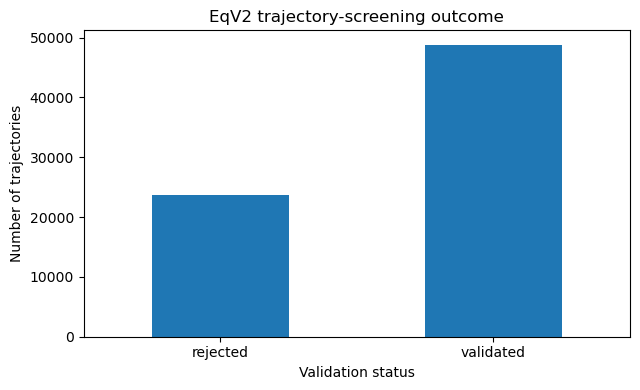

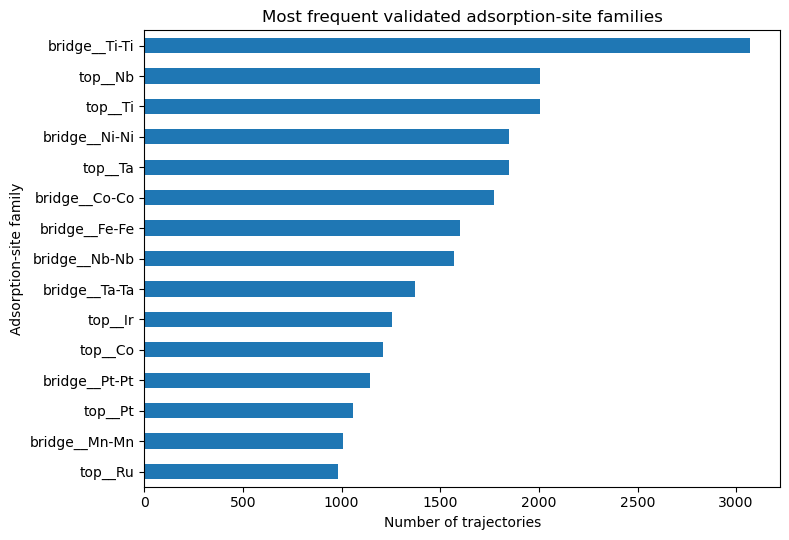

In [15]:
if not df_all_records.empty:
    ax = (
        df_all_records["validation_status"]
        .value_counts()
        .sort_index()
        .plot(kind="bar", figsize=(6.5, 4.0))
    )
    ax.set_title("EqV2 trajectory-screening outcome")
    ax.set_xlabel("Validation status")
    ax.set_ylabel("Number of trajectories")
    ax.tick_params(axis="x", rotation=0)
    plt.tight_layout()
    plt.show()

if not df_validated.empty:
    ax = (
        df_validated["site_family"]
        .value_counts()
        .head(15)
        .sort_values()
        .plot(kind="barh", figsize=(8.0, 5.5))
    )
    ax.set_title("Most frequent validated adsorption-site families")
    ax.set_xlabel("Number of trajectories")
    ax.set_ylabel("Adsorption-site family")
    plt.tight_layout()
    plt.show()

## 9. Dynamic inspection of an actual processed trajectory

This cell does not hard-code a material or trajectory filename. It displays the first global minimum found in the processed dataset.

In [16]:
if df_global_minima.empty:
    print("No global minimum is available because no trajectory passed screening.")
else:
    columns = [
        "system_id",
        "material_id",
        "facet",
        "adsorbate",
        "trajectory_order",
        "trajectory_label",
        "configuration_index",
        "trajectory_filename",
        "trajectory_file",
        "chemical_formula",
        "final_total_energy_eV",
        "relative_energy_within_system_eV",
        "final_max_force_eV_per_A",
        "site_type",
        "neighbor_string",
        "neighbor_indices",
        "neighbor_distances_A",
        "site_reason",
    ]
    display(
        df_global_minima[
            [column for column in columns if column in df_global_minima.columns]
        ].head(1)
    )

,system_id,material_id,facet,adsorbate,trajectory_order,trajectory_label,configuration_index,trajectory_filename,trajectory_file,chemical_formula,final_total_energy_eV,relative_energy_within_system_eV,final_max_force_eV_per_A,site_type,neighbor_string,neighbor_indices,neighbor_distances_A,site_reason
0,mp-1007855_100_O,mp-1007855,100,O,3,3,3,3.traj,ORR_EqV2_Relaxation_Trajectories/mp-1007855_10...,Fe24Ni72O,-0.863281,0.0,0.028658,bridge,Ni-Ni,47-59,2.0466;2.0090,projection_bridge


## Output tables

| File | Scientific role |
|---|---|
| `orr_eqv2_all_trajectory_quality_control.csv` | One audit record for **every `.traj` file**, including validation outcome and rejection reason |
| `orr_eqv2_validated_relaxation_trajectories.csv` | Every trajectory passing stoichiometry, anomaly, energy, and force screening |
| `orr_eqv2_unique_adsorption_site_minima.csv` | Minimum-energy representative for every physical unique adsorption site |
| `orr_eqv2_adsorption_site_family_minima.csv` | Minimum-energy representative for every coordination/element site family |
| `orr_eqv2_global_minimum_configuration_per_system.csv` | Lowest-energy validated configuration in every slab–adsorbate folder |
| `orr_eqv2_quality_control_summary_by_system.csv` | Per-folder screening counts and composition-consistency checks |

The unique-site-minimum table is the recommended primary CSV for the article repository. The complete quality-control table records the outcome for every trajectory, including numeric, `config_<n>`, and arbitrary string filenames.


Published adsorption-energy rows: 24,466
Saved clean adsorption-energy CSV: ORR_EqV2_Adsorption_Site_Analysis/orr_eqv2_unique_site_adsorption_energies.csv
Raw rows      : 24,466
After filter  : 24,458  (removed 8 values outside -7 to +7 eV)

Count per adsorbate (filtered):
adsorbate
O      10881
OH      9864
OOH     3713
Name: count, dtype: int64

Mean Eads per adsorbate (filtered):
adsorbate
O     -0.597
OH    -0.764
OOH    2.693
Name: adsorption_energy_eV, dtype: float64
Saved element statistics: ORR_EqV2_Adsorption_Site_Analysis/orr_eqv2_adsorption_energy_statistics_by_element.csv
Saved: ORR_EqV2_Adsorption_Site_Analysis/adsorption_energy_figures/fig1_histograms.png
Saved: ORR_EqV2_Adsorption_Site_Analysis/adsorption_energy_figures/fig1_histograms.pdf


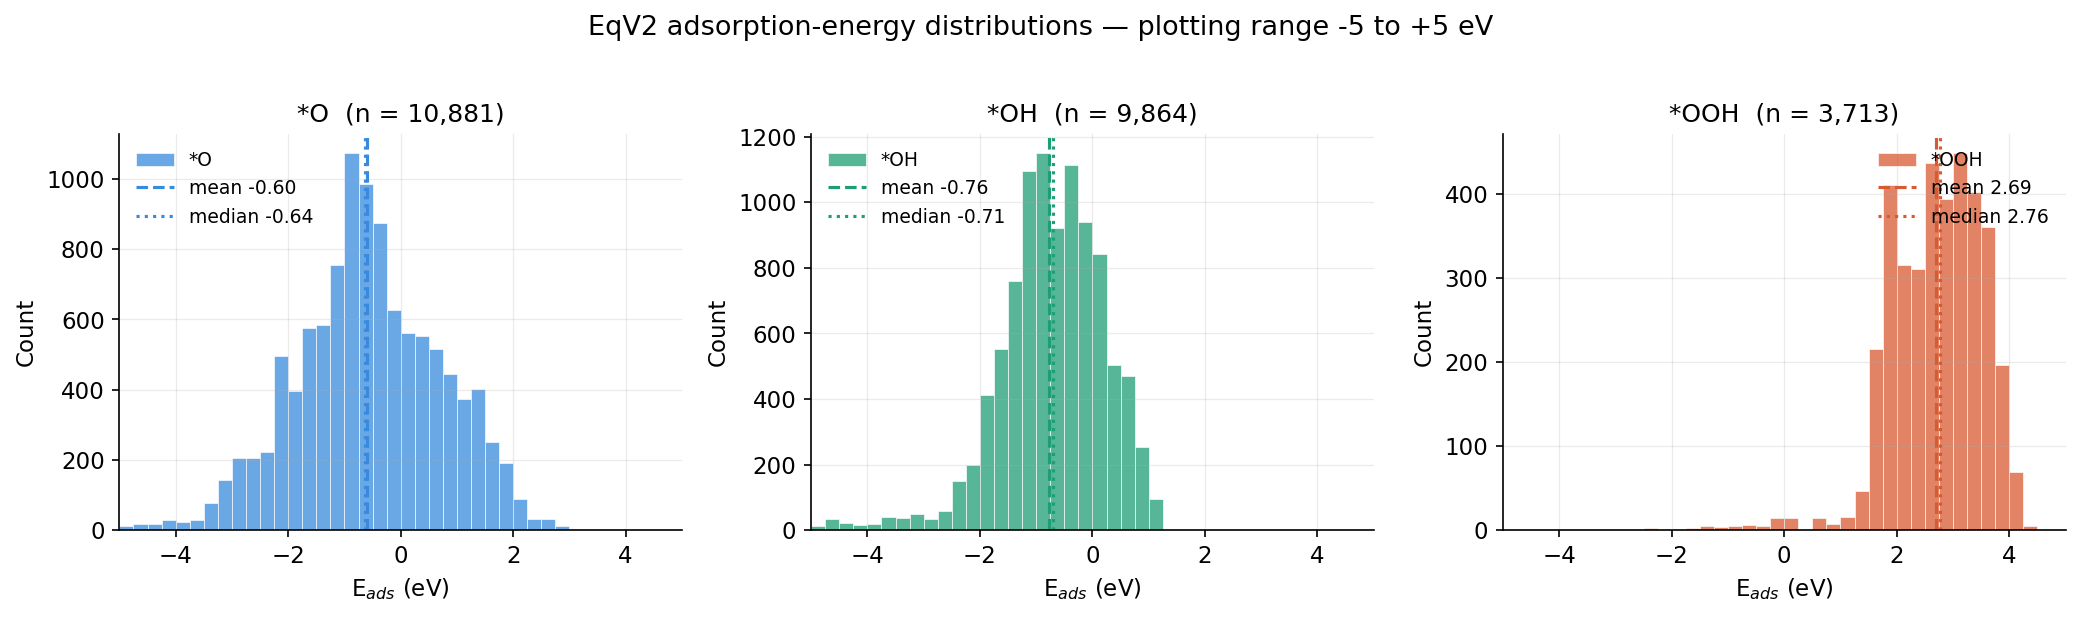

Saved: ORR_EqV2_Adsorption_Site_Analysis/adsorption_energy_figures/fig2_violin_per_element.png
Saved: ORR_EqV2_Adsorption_Site_Analysis/adsorption_energy_figures/fig2_violin_per_element.pdf


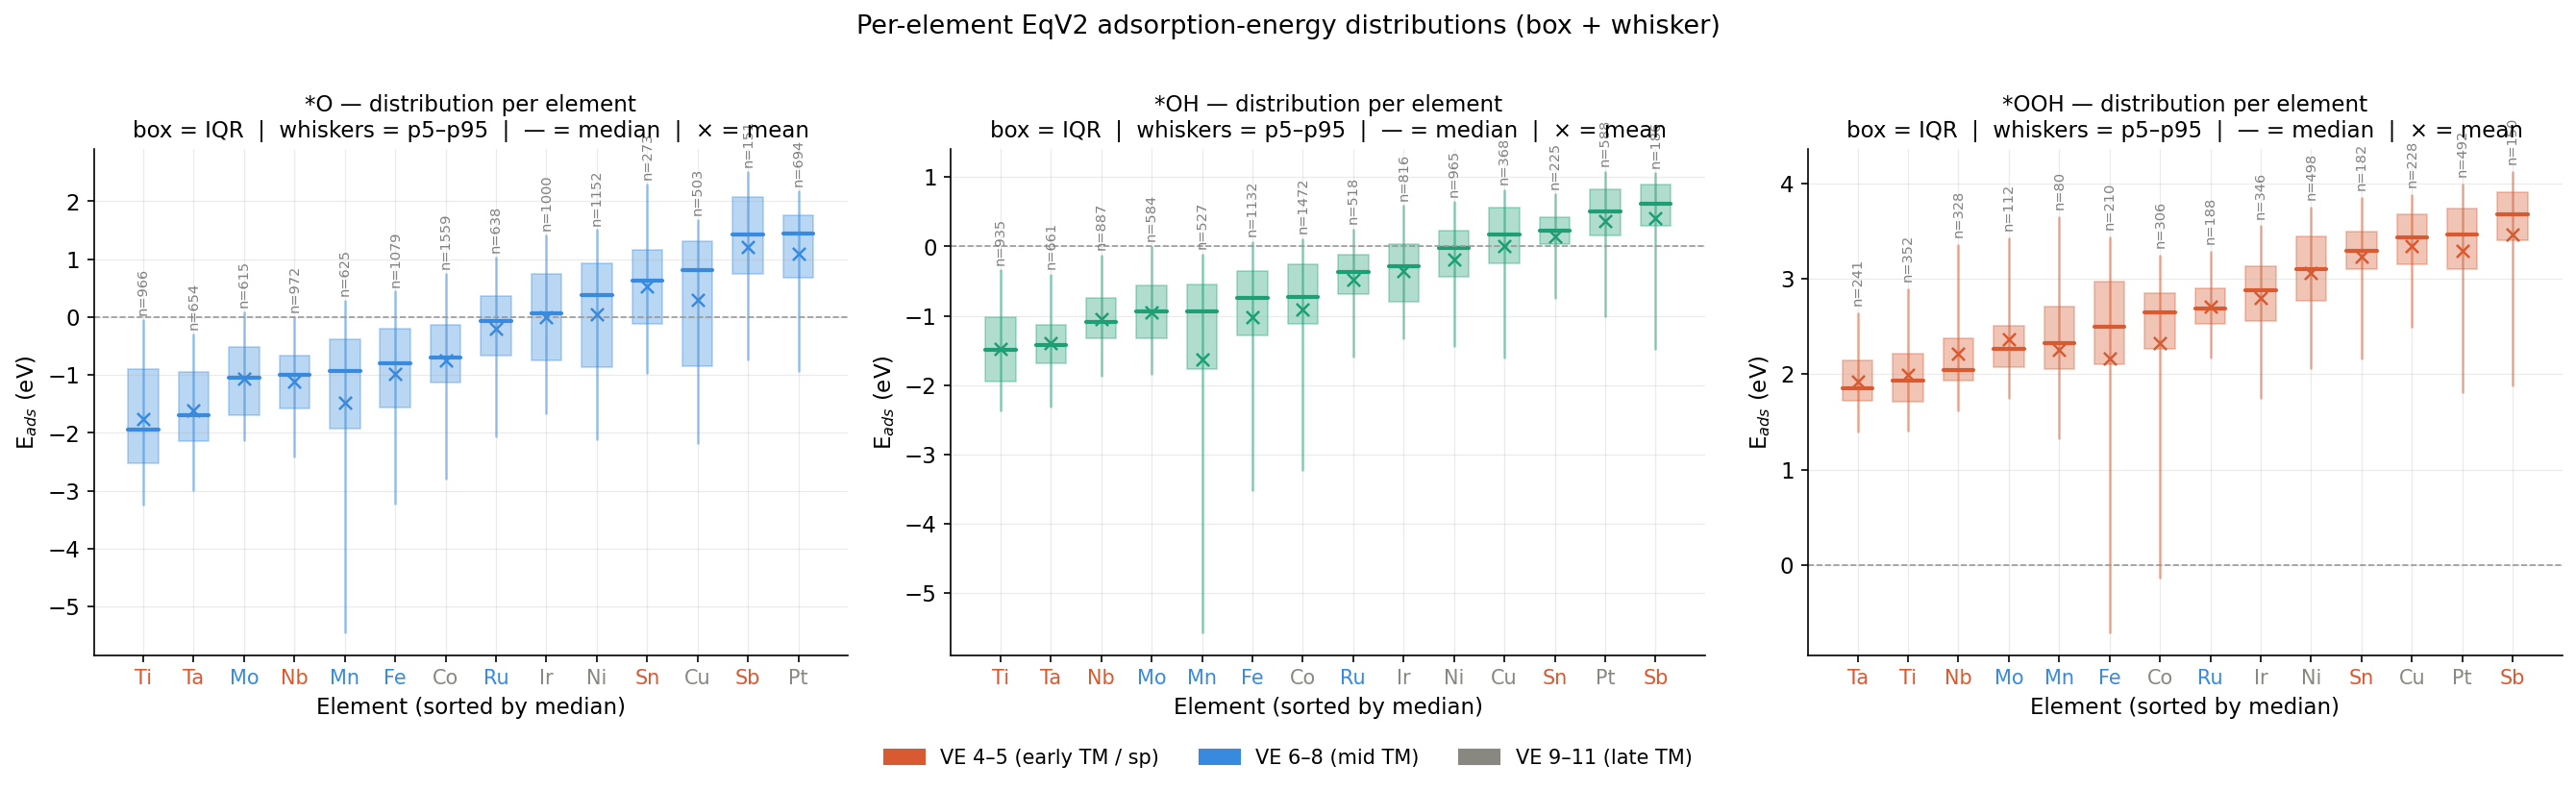

Saved: ORR_EqV2_Adsorption_Site_Analysis/adsorption_energy_figures/fig3_10electron_rule.png
Saved: ORR_EqV2_Adsorption_Site_Analysis/adsorption_energy_figures/fig3_10electron_rule.pdf


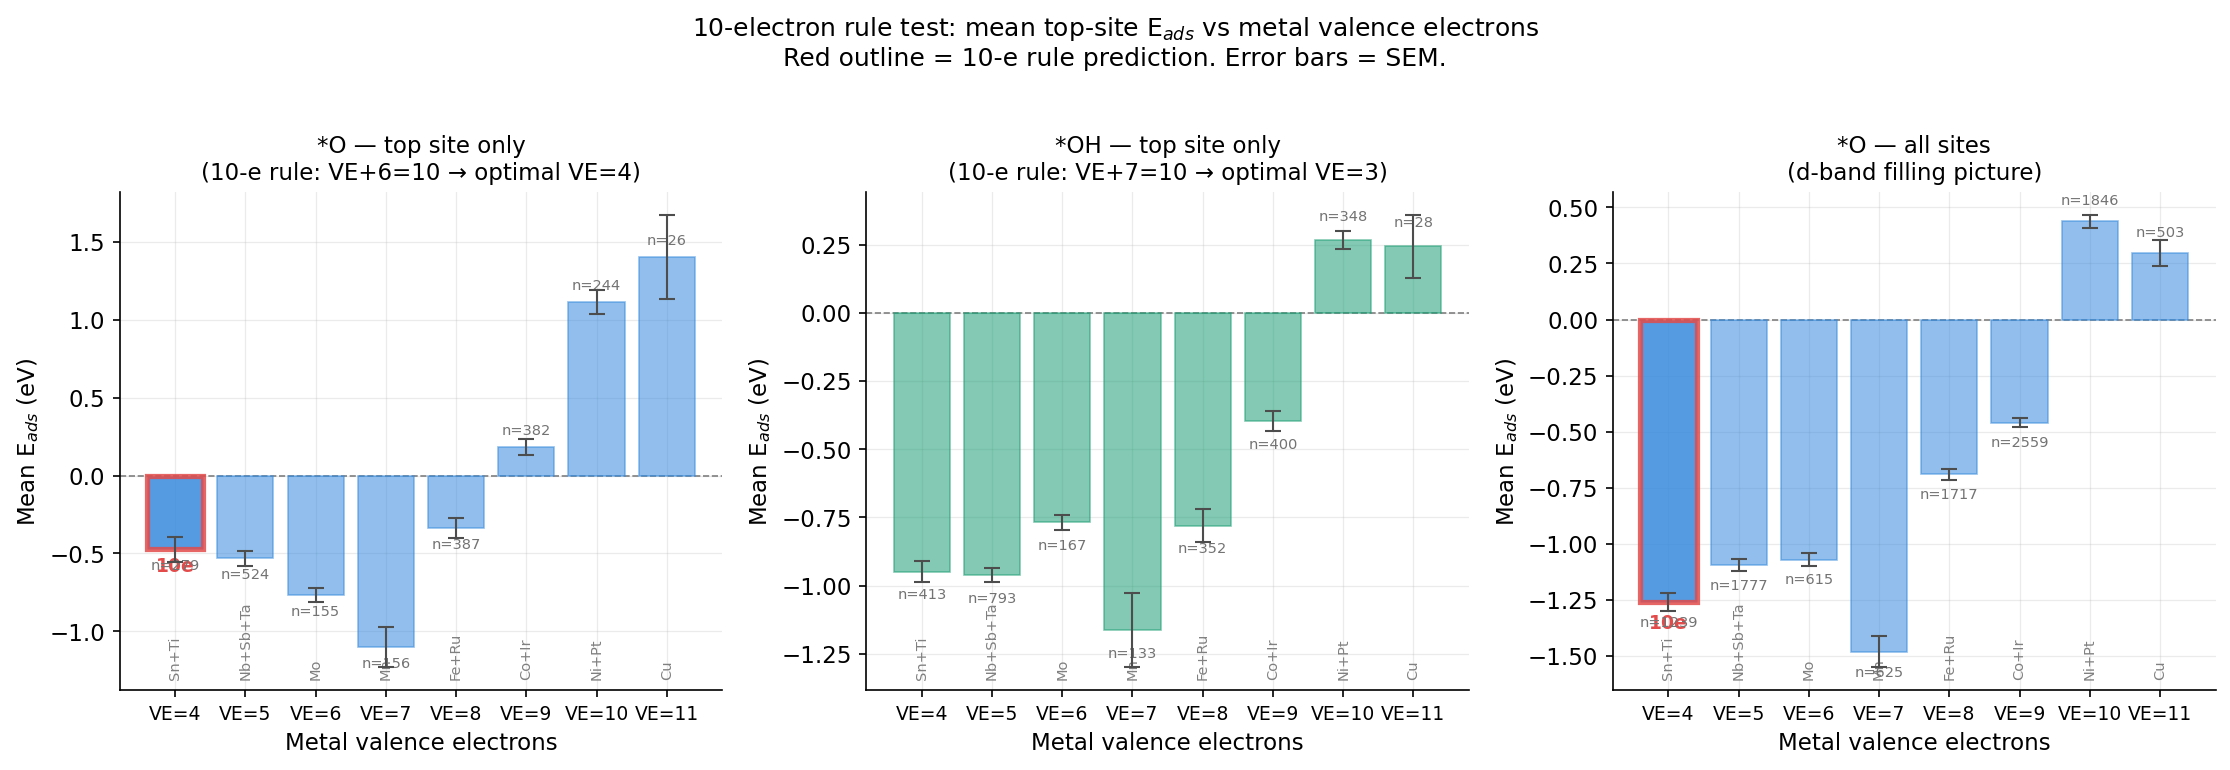

Saved: ORR_EqV2_Adsorption_Site_Analysis/adsorption_energy_figures/fig4_site_breakdown.png
Saved: ORR_EqV2_Adsorption_Site_Analysis/adsorption_energy_figures/fig4_site_breakdown.pdf


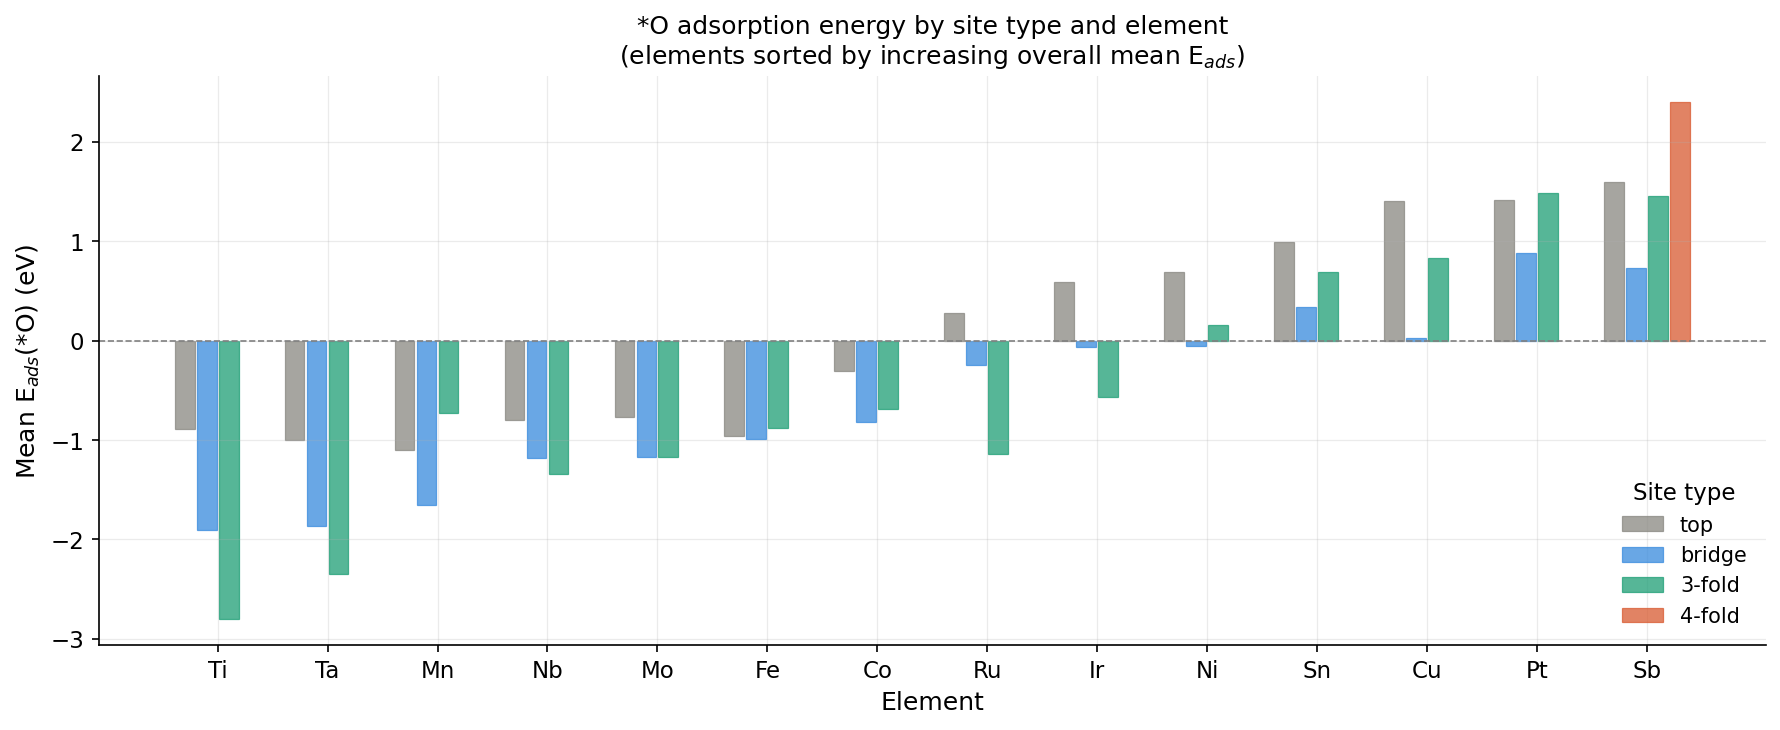

Saved: ORR_EqV2_Adsorption_Site_Analysis/adsorption_energy_figures/fig5_EN_vs_Eads.png
Saved: ORR_EqV2_Adsorption_Site_Analysis/adsorption_energy_figures/fig5_EN_vs_Eads.pdf


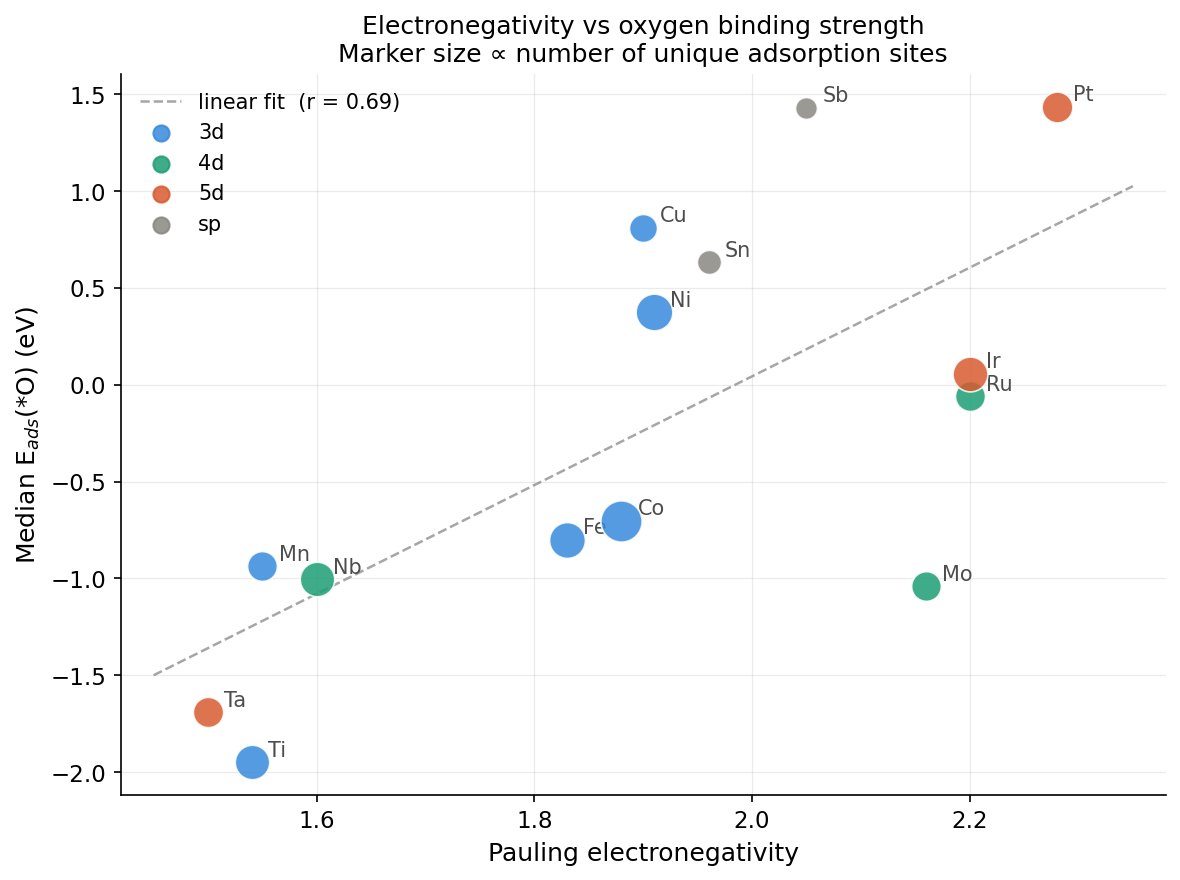

Saved: ORR_EqV2_Adsorption_Site_Analysis/adsorption_energy_figures/fig6_screening_window.png
Saved: ORR_EqV2_Adsorption_Site_Analysis/adsorption_energy_figures/fig6_screening_window.pdf


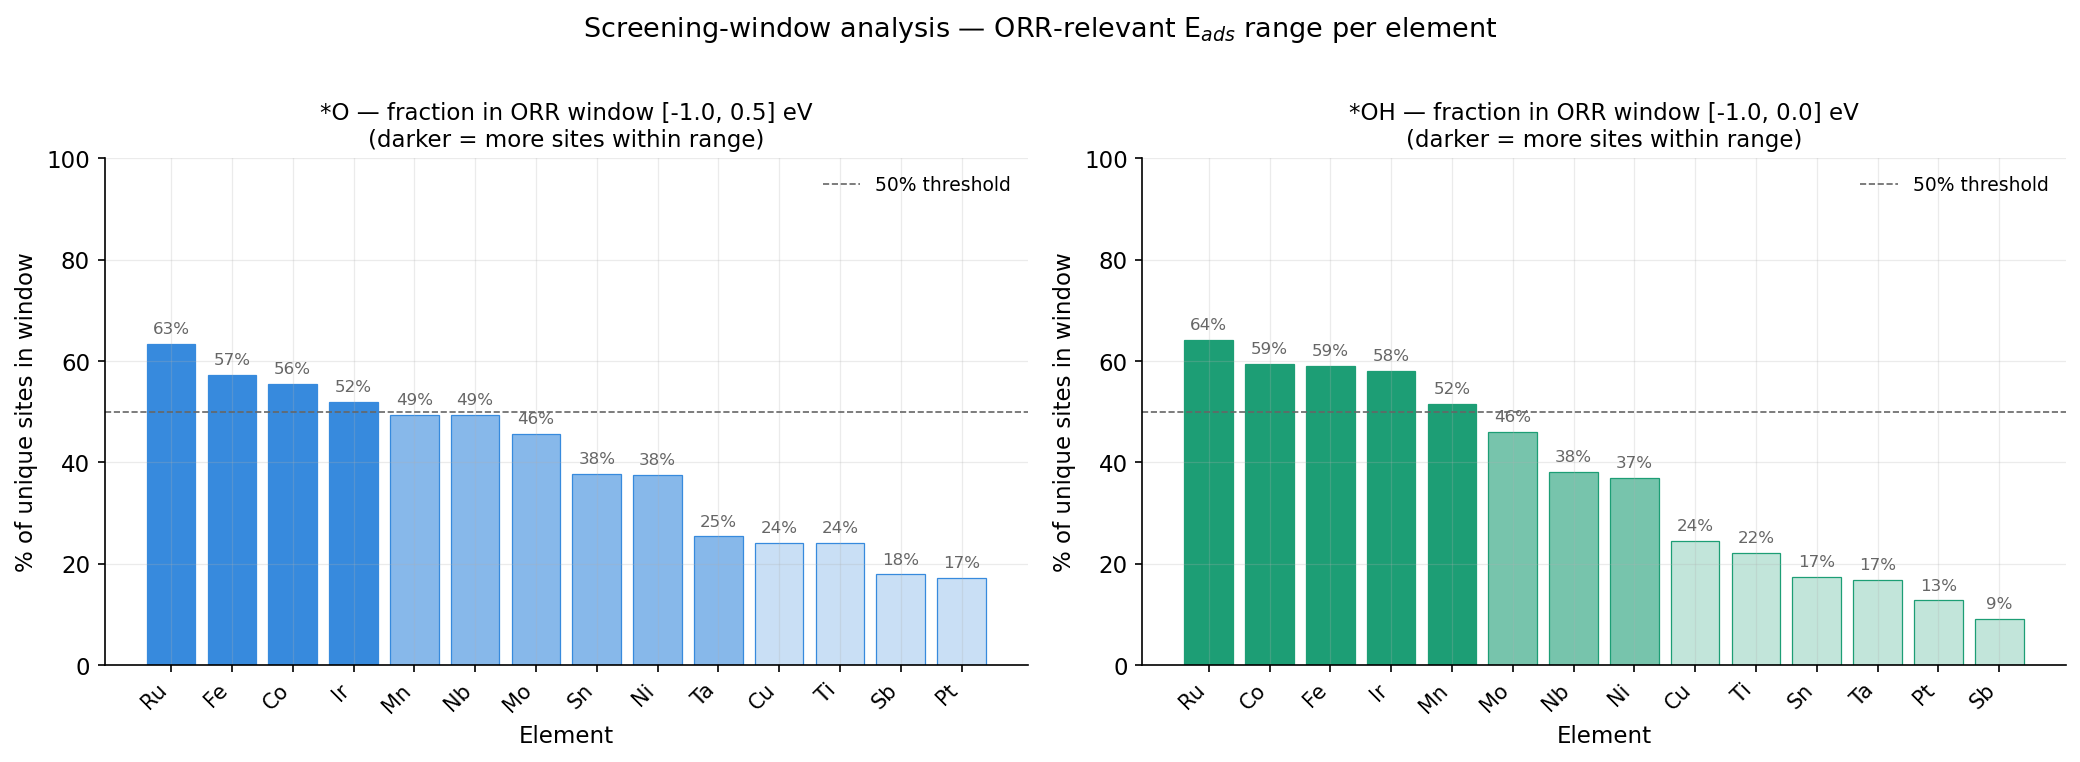

Saved: ORR_EqV2_Adsorption_Site_Analysis/adsorption_energy_figures/fig7_ridge_plots.png
Saved: ORR_EqV2_Adsorption_Site_Analysis/adsorption_energy_figures/fig7_ridge_plots.pdf


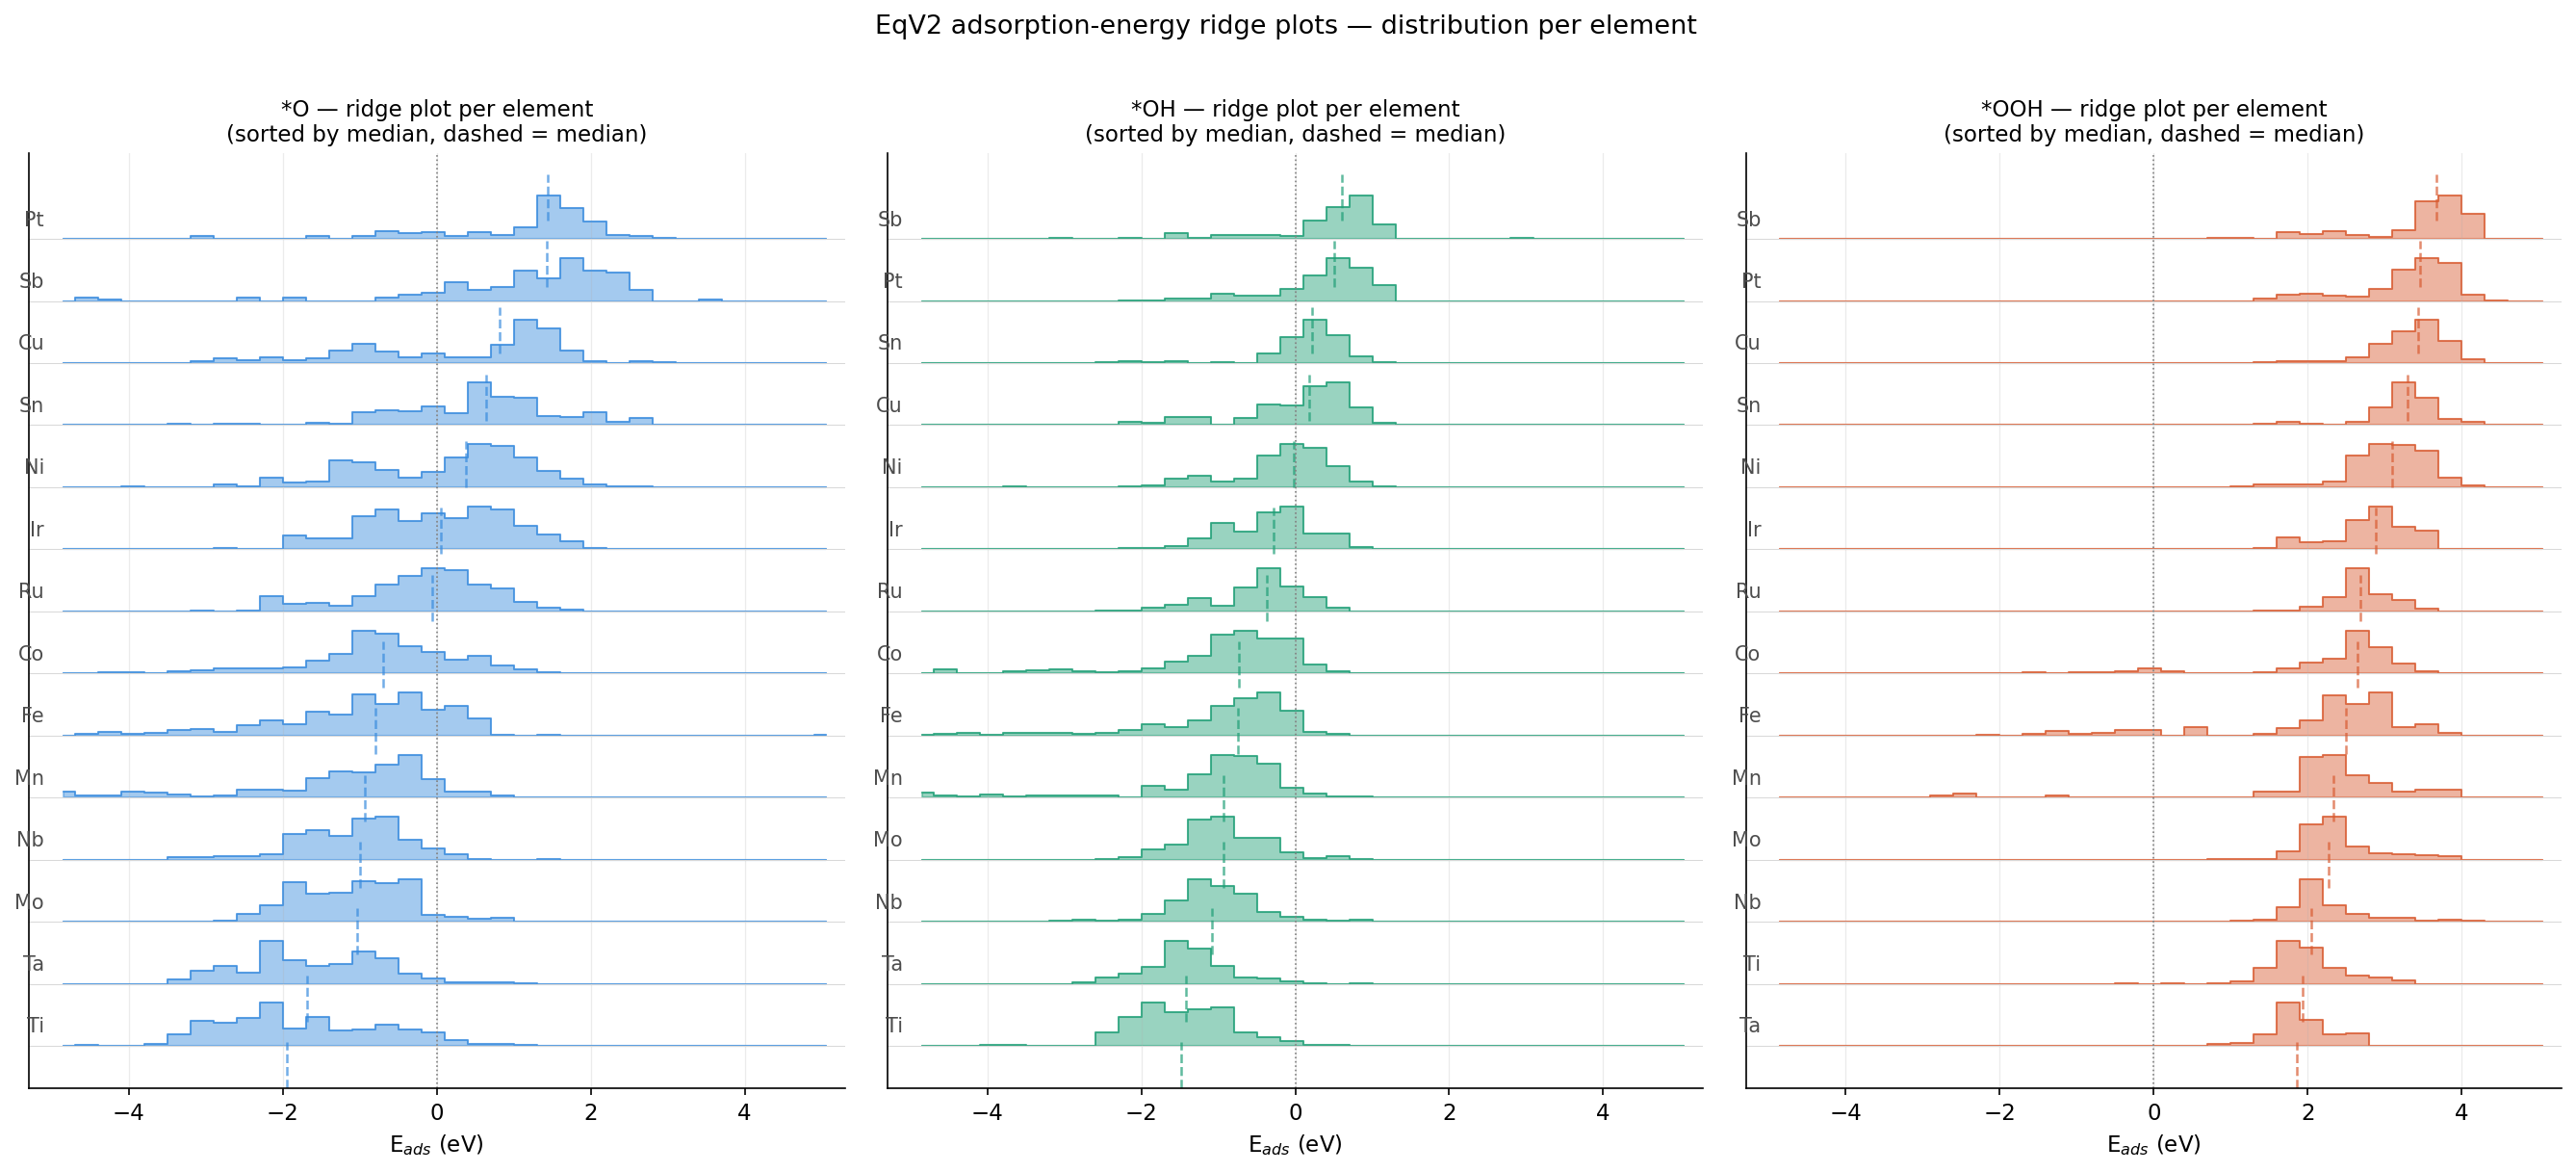

Saved: ORR_EqV2_Adsorption_Site_Analysis/adsorption_energy_figures/fig8_VE_vs_Eads_range.png
Saved: ORR_EqV2_Adsorption_Site_Analysis/adsorption_energy_figures/fig8_VE_vs_Eads_range.pdf


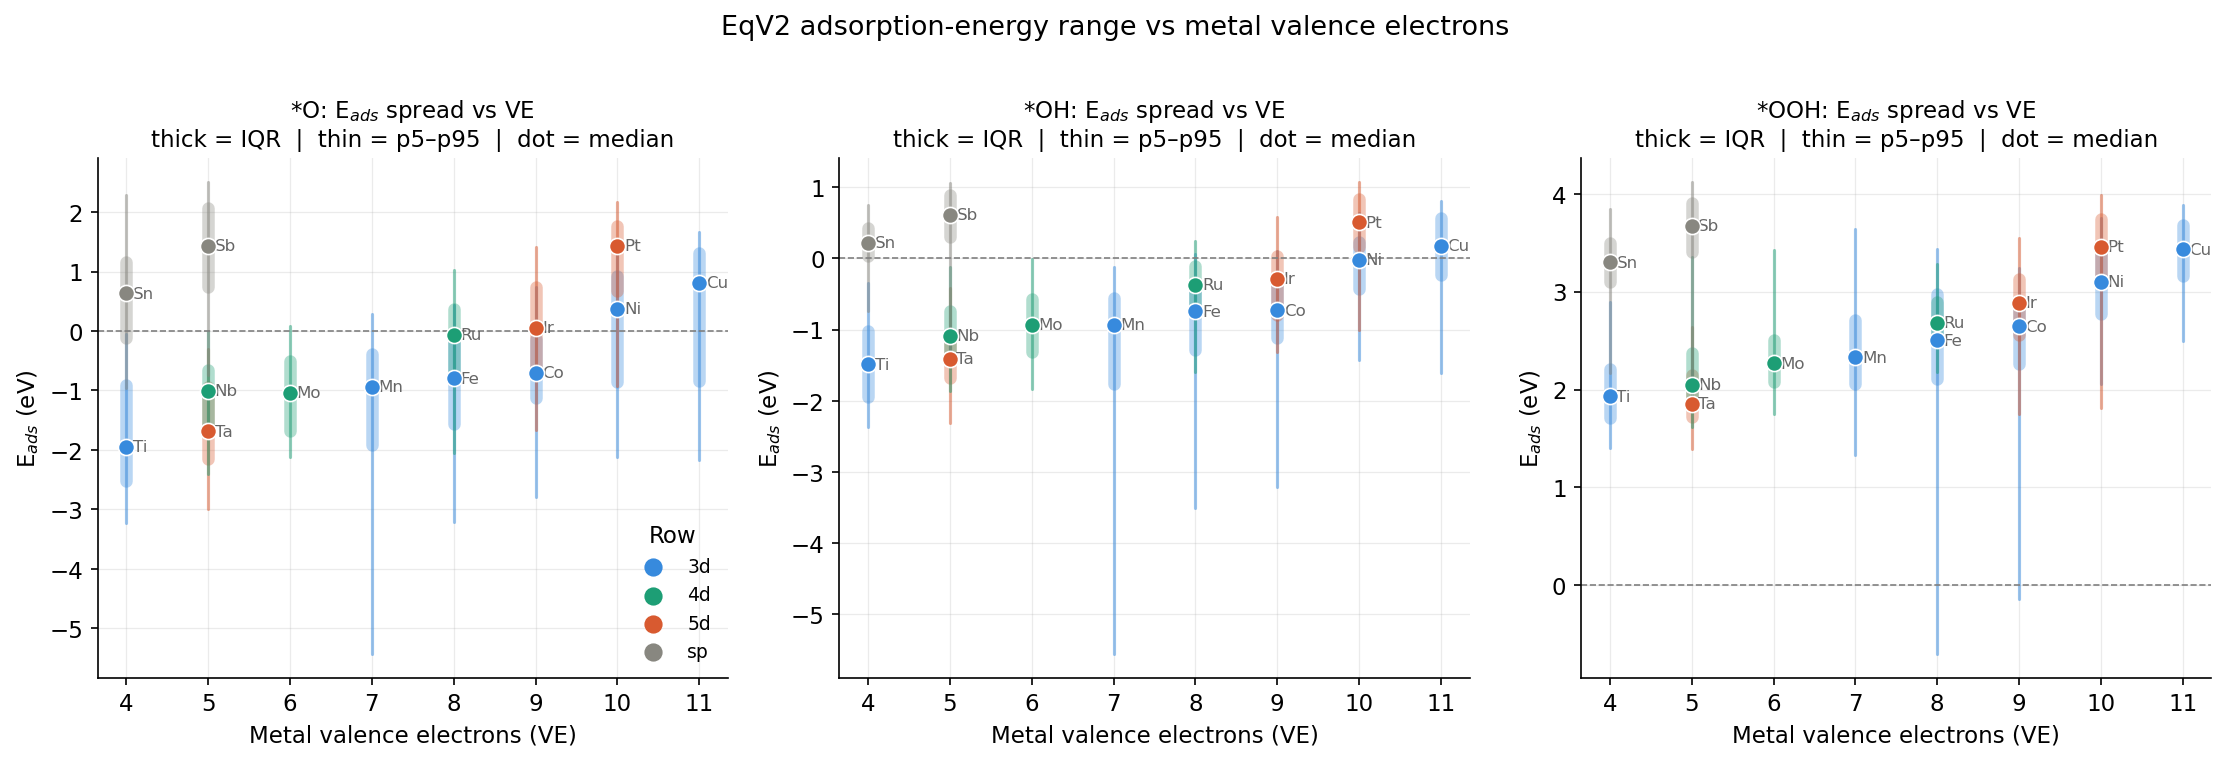

SUMMARY STATISTICS (unique-site minima; filtered -7 to +7 eV)

────────────────────────────────────────
  *O
────────────────────────────────────────
  Element     n   VE      p5     p25   median    mean     p75     p95    std
  Ti       966    4   -3.23   -2.53    -1.95   -1.77   -0.90   -0.05   1.07
  Ta       654    5   -2.99   -2.15    -1.69   -1.61   -0.94   -0.30   0.87
  Mo       615    6   -2.12   -1.69    -1.04   -1.07   -0.51    0.08   0.73
  Nb       972    5   -2.41   -1.58    -1.00   -1.11   -0.66   -0.00   0.73
  Mn       625    7   -5.44   -1.93    -0.94   -1.48   -0.39    0.28   1.73
  Fe      1079    8   -3.22   -1.56    -0.80   -0.98   -0.20    0.44   1.13
  Co      1559    9   -2.79   -1.12    -0.70   -0.75   -0.13    0.75   1.05
  Ru       638    8   -2.06   -0.66    -0.06   -0.21    0.37    1.03   0.88
  Ir      1000    9   -1.67   -0.75     0.06   -0.01    0.74    1.41   0.94
  Ni      1152   10   -2.12   -0.86     0.37    0.04    0.92    1.50   1.20
  Sn       27

In [20]:
# %% [markdown]
# # Adsorption Energy Distribution Analysis
# ### EqV2 ORR screening — *O, *OH, *OOH across bimetallic surfaces
#
# Paste this section directly AFTER the output-table/export cell of:
# ORR_EqV2_All_Trajectory_Screening_and_Site_Analysis.ipynb
#
# The code uses `df_unique_minima` already created by the notebook.

# %% [markdown]
# ## 0. Imports and setup

# %%
from pathlib import Path
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import MultipleLocator

warnings.filterwarnings("ignore")

# ── figure style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 150,
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.6,
    "legend.framealpha": 0.9,
    "legend.edgecolor": "0.8",
})

# ── colours ───────────────────────────────────────────────────────────────────
C = {"O": "#378ADD", "OH": "#1D9E75", "OOH": "#D85A30"}
SITE_COLS = {
    "top": "#888780",
    "bridge": "#378ADD",
    "3-fold": "#1D9E75",
    "4-fold": "#D85A30",
}
GRP_COLS = {"3d": "#378ADD", "4d": "#1D9E75", "5d": "#D85A30", "sp": "#888780"}

# Output folders
FIGURE_DIR = OUTPUT_DIR / "adsorption_energy_figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Publication-oriented processed CSV
ADSORPTION_ENERGY_CSV = (
    OUTPUT_DIR / "orr_eqv2_unique_site_adsorption_energies.csv"
)
ELEMENT_STATS_CSV = (
    OUTPUT_DIR / "orr_eqv2_adsorption_energy_statistics_by_element.csv"
)


def save_figure(fig, filename_stem: str) -> None:
    """Save both a high-resolution PNG and an editable vector PDF."""
    png_path = FIGURE_DIR / f"{filename_stem}.png"
    pdf_path = FIGURE_DIR / f"{filename_stem}.pdf"
    fig.savefig(png_path, dpi=600, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    print(f"Saved: {png_path}")
    print(f"Saved: {pdf_path}")


# %% [markdown]
# ## 1. Prepare and export the adsorption-energy dataset

# %%
# The screening notebook already produced one minimum-energy row per physical
# unique adsorption site in `df_unique_minima`.
if "df_unique_minima" not in globals():
    raise NameError(
        "df_unique_minima is not available. Run the trajectory screening, "
        "energy ranking, and output-table cells first."
    )

required_columns = {
    "system_id",
    "material_id",
    "facet",
    "surface_id",
    "adsorbate",
    "site_type",
    "neighbor_string",
    "final_total_energy_eV",
}
missing_columns = sorted(required_columns - set(df_unique_minima.columns))

if missing_columns:
    raise KeyError(
        "df_unique_minima is missing required columns: "
        f"{missing_columns}"
    )

# Rename the EqV2 output to its scientific meaning in the publishable table.
df = df_unique_minima.copy().rename(
    columns={"final_total_energy_eV": "adsorption_energy_eV"}
)

# Put the most useful publication columns first while retaining every original
# metadata/QC column after them.
preferred_columns = [
    "system_id",
    "material_id",
    "facet",
    "surface_id",
    "adsorbate",
    "trajectory_order",
    "trajectory_label",
    "configuration_index",
    "trajectory_filename",
    "trajectory_relative_path",
    "adsorption_energy_eV",
    "final_max_force_eV_per_A",
    "site_type",
    "neighbor_string",
    "neighbor_indices",
    "neighbor_distances_A",
    "site_family",
    "site_reason",
    "unique_site_key",
]

ordered_columns = [column for column in preferred_columns if column in df.columns]
remaining_columns = [column for column in df.columns if column not in ordered_columns]
df = df[ordered_columns + remaining_columns]

# Sort consistently for repository use.
sort_columns = [
    column
    for column in [
        "material_id",
        "facet",
        "adsorbate",
        "adsorption_energy_eV",
        "trajectory_order",
    ]
    if column in df.columns
]
df = df.sort_values(sort_columns, na_position="last").reset_index(drop=True)

# Export the clean ACS Catalysis repository table.
df.to_csv(ADSORPTION_ENERGY_CSV, index=False)

print(f"Published adsorption-energy rows: {len(df):,}")
print(f"Saved clean adsorption-energy CSV: {ADSORPTION_ENERGY_CSV}")

# Apply the same broad anomaly-display filter used in the supplied figure code.
# The figures themselves show the central -5 to +5 eV range.
df_f = df[
    df["adsorption_energy_eV"].between(-7.0, 7.0, inclusive="both")
].copy()

print(f"Raw rows      : {len(df):,}")
print(
    f"After filter  : {len(df_f):,}  "
    f"(removed {len(df) - len(df_f):,} values outside -7 to +7 eV)"
)
print()
print("Count per adsorbate (filtered):")
print(df_f["adsorbate"].value_counts().reindex(["O", "OH", "OOH"]).fillna(0).astype(int))
print()
print("Mean Eads per adsorbate (filtered):")
print(
    df_f.groupby("adsorbate")["adsorption_energy_eV"]
    .mean()
    .reindex(["O", "OH", "OOH"])
    .round(3)
)


# %% [markdown]
# ## 2. Helper — per-element statistics

# %%
# Element metadata
TOTAL_VE = {
    "Ti": 4,  "Ta": 5,  "Mn": 7,  "Fe": 8,  "Nb": 5,
    "Mo": 6,  "Co": 9,  "Ru": 8,  "Ni": 10, "Ir": 9,
    "Cu": 11, "Sn": 4,  "Pt": 10, "Sb": 5,
}
EN_PAULING = {
    "Ti": 1.54, "Ta": 1.50, "Mn": 1.55, "Fe": 1.83, "Nb": 1.60,
    "Mo": 2.16, "Co": 1.88, "Ru": 2.20, "Ni": 1.91, "Ir": 2.20,
    "Cu": 1.90, "Sn": 1.96, "Pt": 2.28, "Sb": 2.05,
}
PERIOD_GRP = {
    "Ti": "3d", "Mn": "3d", "Fe": "3d", "Co": "3d", "Ni": "3d", "Cu": "3d",
    "Nb": "4d", "Mo": "4d", "Ru": "4d",
    "Ta": "5d", "Ir": "5d", "Pt": "5d",
    "Sn": "sp", "Sb": "sp",
}

# Preserve the supplied analysis convention: use the first alphabetically
# ordered directly coordinating element from neighbor_string.
df_f["primary"] = (
    df_f["neighbor_string"]
    .astype("string")
    .str.split("-")
    .str[0]
)

df_k = df_f[df_f["primary"].isin(TOTAL_VE)].copy()
df_k["total_ve"] = df_k["primary"].map(TOTAL_VE)
df_k["EN"] = df_k["primary"].map(EN_PAULING)
df_k["grp"] = df_k["primary"].map(PERIOD_GRP)


def elem_stats(ads: str) -> pd.DataFrame:
    """Return per-element quantile statistics, sorted by median Eads."""
    sub = df_k[df_k["adsorbate"] == ads]
    rows = []

    for element, group in sub.groupby("primary"):
        values = group["adsorption_energy_eV"].dropna().to_numpy(dtype=float)
        if len(values) == 0:
            continue

        rows.append({
            "el": element,
            "ve": TOTAL_VE[element],
            "EN": EN_PAULING[element],
            "grp": PERIOD_GRP[element],
            "p5": np.percentile(values, 5),
            "p25": np.percentile(values, 25),
            "p50": np.percentile(values, 50),
            "p75": np.percentile(values, 75),
            "p95": np.percentile(values, 95),
            "mean": np.mean(values),
            "std": np.std(values),
            "count": len(values),
        })

    if not rows:
        return pd.DataFrame(
            columns=[
                "el", "ve", "EN", "grp", "p5", "p25", "p50",
                "p75", "p95", "mean", "std", "count",
            ]
        )

    return pd.DataFrame(rows).sort_values("p50").reset_index(drop=True)


stats = {ads: elem_stats(ads) for ads in ["O", "OH", "OOH"]}

# Export the statistics used in Figures 2, 5, 7, and 8.
stats_to_export = []
for adsorbate, table in stats.items():
    if table.empty:
        continue
    current = table.copy()
    current.insert(0, "adsorbate", adsorbate)
    stats_to_export.append(current)

if stats_to_export:
    df_element_stats = pd.concat(stats_to_export, ignore_index=True)
    df_element_stats.to_csv(ELEMENT_STATS_CSV, index=False)
    print(f"Saved element statistics: {ELEMENT_STATS_CSV}")


# %% [markdown]
# ## 3. Figure 1 — Histograms for O, OH, and OOH

# %%
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
bins = np.arange(-5, 5.26, 0.25)

for ax, ads in zip(axes, ["O", "OH", "OOH"]):
    data = df_f.loc[
        df_f["adsorbate"] == ads,
        "adsorption_energy_eV",
    ].dropna()

    ax.hist(
        data,
        bins=bins,
        color=C[ads],
        alpha=0.75,
        edgecolor="white",
        linewidth=0.4,
        label=f"*{ads}",
    )

    if not data.empty:
        ax.axvline(
            data.mean(),
            color=C[ads],
            lw=1.5,
            ls="--",
            label=f"mean {data.mean():.2f}",
        )
        ax.axvline(
            data.median(),
            color=C[ads],
            lw=1.5,
            ls=":",
            label=f"median {data.median():.2f}",
        )

    ax.set_xlabel("E$_{ads}$ (eV)", fontsize=11)
    ax.set_ylabel("Count", fontsize=11)
    ax.set_title(f"*{ads}  (n = {len(data):,})", fontsize=12, fontweight="normal")
    ax.legend(fontsize=9, loc="upper right" if ads == "OOH" else "upper left")
    ax.set_xlim(-5, 5)

fig.suptitle(
    "EqV2 adsorption-energy distributions — plotting range -5 to +5 eV",
    fontsize=13,
    y=1.02,
)
fig.tight_layout()
save_figure(fig, "fig1_histograms")
plt.show()


# %% [markdown]
# ## 4. Figure 2 — Box/whisker plots per element

# %%
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for ax, ads in zip(axes, ["O", "OH", "OOH"]):
    st = stats[ads]
    n = len(st)
    col = C[ads]

    for i, row in st.iterrows():
        # Whisker: p5–p95
        ax.plot(
            [i, i],
            [row.p5, row.p95],
            color=col,
            lw=1.2,
            alpha=0.5,
            solid_capstyle="round",
        )

        # IQR box
        box_h = row.p75 - row.p25
        rect = mpatches.FancyBboxPatch(
            (i - 0.3, row.p25),
            0.6,
            box_h,
            boxstyle="square,pad=0",
            linewidth=0.8,
            edgecolor=col,
            facecolor=col,
            alpha=0.35,
        )
        ax.add_patch(rect)

        # Median line
        ax.plot(
            [i - 0.3, i + 0.3],
            [row.p50, row.p50],
            color=col,
            lw=2.0,
            solid_capstyle="round",
        )

        # Mean cross
        ax.scatter(
            i,
            row["mean"],
            marker="x",
            s=40,
            color=col,
            zorder=5,
            linewidths=1.2,
        )

    ax.set_xticks(range(n))
    ax.set_xticklabels(st["el"], fontsize=10)
    ax.set_xlabel("Element (sorted by median)", fontsize=11)
    ax.set_ylabel("E$_{ads}$ (eV)", fontsize=11)
    ax.set_title(
        f"*{ads} — distribution per element\n"
        "box = IQR  |  whiskers = p5–p95  |  — = median  |  × = mean",
        fontsize=11,
    )

    for i, row in st.iterrows():
        ax.text(
            i,
            row.p95 + 0.08,
            f"n={int(row['count'])}",
            ha="center",
            va="bottom",
            fontsize=7,
            color="0.5",
            rotation=90,
        )

    # Colour element labels by valence-electron range.
    for i, row in st.iterrows():
        ax.get_xticklabels()[i].set_color(
            "#D85A30" if row.ve <= 5
            else "#378ADD" if row.ve <= 8
            else "#888780"
        )

    ax.axhline(0, color="0.6", lw=0.8, ls="--")

leg_patches = [
    mpatches.Patch(color="#D85A30", label="VE 4–5 (early TM / sp)"),
    mpatches.Patch(color="#378ADD", label="VE 6–8 (mid TM)"),
    mpatches.Patch(color="#888780", label="VE 9–11 (late TM)"),
]
fig.legend(
    handles=leg_patches,
    loc="lower center",
    ncol=3,
    fontsize=10,
    bbox_to_anchor=(0.5, -0.06),
)

fig.suptitle(
    "Per-element EqV2 adsorption-energy distributions (box + whisker)",
    fontsize=13,
    y=1.01,
)
fig.tight_layout()
save_figure(fig, "fig2_violin_per_element")
plt.show()


# %% [markdown]
# ## 5. Figure 3 — 10-electron rule: top-site mean Eads vs metal VE

# %%
ve_labels = [4, 5, 6, 7, 8, 9, 10, 11]


def ve_summary(adsorbate: str, site_selection: str) -> dict:
    """Build the original VE-binned mean/std/count dataset from df_k."""
    subset = df_k[df_k["adsorbate"] == adsorbate].copy()

    if site_selection == "top":
        subset = subset[subset["site_type"] == "top"].copy()
    elif site_selection != "all":
        raise ValueError("site_selection must be 'top' or 'all'.")

    grouped = subset.groupby("total_ve")

    means = []
    stds = []
    counts = []
    element_labels = []

    for ve in ve_labels:
        if ve not in grouped.groups:
            means.append(np.nan)
            stds.append(np.nan)
            counts.append(0)
            element_labels.append("")
            continue

        group = grouped.get_group(ve)
        values = group["adsorption_energy_eV"].dropna().to_numpy(dtype=float)

        means.append(float(np.mean(values)))
        stds.append(float(np.std(values)))
        counts.append(int(len(values)))
        element_labels.append(
            "+".join(sorted(group["primary"].dropna().unique()))
        )

    return {
        "means": means,
        "stds": stds,
        "counts": counts,
        "elems": element_labels,
    }


topsite_O = ve_summary("O", "top")
topsite_OH = ve_summary("OH", "top")
allsite_O = ve_summary("O", "all")

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)
datasets = [
    (
        topsite_O,
        "O",
        "top",
        "*O — top site only\n(10-e rule: VE+6=10 → optimal VE=4)",
    ),
    (
        topsite_OH,
        "OH",
        "top",
        "*OH — top site only\n(10-e rule: VE+7=10 → optimal VE=3)",
    ),
    (
        allsite_O,
        "O",
        "all",
        "*O — all sites\n(d-band filling picture)",
    ),
]

for ax, (dat, ads, sites, title) in zip(axes, datasets):
    x = np.arange(len(ve_labels))
    col = C[ads]

    bars = ax.bar(
        x,
        dat["means"],
        color=col,
        alpha=0.55,
        edgecolor=col,
        linewidth=0.8,
        zorder=3,
    )

    # Highlight the 10-electron-rule prediction.
    ads_ve = 6 if ads == "O" else 7
    for i, (ve, bar) in enumerate(zip(ve_labels, bars)):
        mean_value = dat["means"][i]

        if ve + ads_ve == 10 and np.isfinite(mean_value):
            bar.set_edgecolor("#E24B4A")
            bar.set_linewidth(2.5)
            bar.set_alpha(0.85)
            ax.text(
                i,
                mean_value - 0.05 if mean_value < 0 else mean_value + 0.05,
                "10e",
                ha="center",
                va="top" if mean_value < 0 else "bottom",
                fontsize=9,
                color="#E24B4A",
                fontweight="bold",
            )

    # Error bars: standard error of the mean.
    errors = [
        std / np.sqrt(count)
        if count > 0 and np.isfinite(std)
        else np.nan
        for std, count in zip(dat["stds"], dat["counts"])
    ]

    ax.errorbar(
        x,
        dat["means"],
        yerr=errors,
        fmt="none",
        color="0.3",
        capsize=4,
        capthick=1,
        elinewidth=1,
        zorder=4,
    )

    # Annotate the elements represented by each VE bin.
    for i, (elements, count) in enumerate(zip(dat["elems"], dat["counts"])):
        if count == 0:
            continue
        ax.text(
            i,
            0.02,
            elements,
            ha="center",
            va="bottom",
            fontsize=7,
            color="0.5",
            transform=ax.get_xaxis_transform(),
            rotation=90,
        )

    ax.set_xticks(x)
    ax.set_xticklabels([f"VE={ve}" for ve in ve_labels], fontsize=9)
    ax.set_xlabel("Metal valence electrons", fontsize=11)
    ax.set_ylabel("Mean E$_{ads}$ (eV)", fontsize=11)
    ax.set_title(title, fontsize=11)
    ax.axhline(0, color="0.5", lw=0.8, ls="--")

    for i, (mean_value, count) in enumerate(zip(dat["means"], dat["counts"])):
        if count == 0 or not np.isfinite(mean_value):
            continue
        offset = -0.06 if mean_value < 0 else 0.06
        ax.text(
            i,
            mean_value + offset,
            f"n={count}",
            ha="center",
            va="top" if mean_value < 0 else "bottom",
            fontsize=7,
            color="0.45",
        )

fig.suptitle(
    "10-electron rule test: mean top-site E$_{ads}$ vs metal valence electrons\n"
    "Red outline = 10-e rule prediction. Error bars = SEM.",
    fontsize=12,
    y=1.02,
)
fig.tight_layout()
save_figure(fig, "fig3_10electron_rule")
plt.show()


# %% [markdown]
# ## 6. Figure 4 — Site-type breakdown per element (*O)

# %%
sites = ["top", "bridge", "3-fold", "4-fold"]

site_table = (
    df_k[
        (df_k["adsorbate"] == "O")
        & (df_k["site_type"].isin(sites))
    ]
    .pivot_table(
        index="primary",
        columns="site_type",
        values="adsorption_energy_eV",
        aggfunc="mean",
    )
    .reindex(columns=sites)
)

# Sort elements by their overall mean oxygen adsorption energy.
site_table = site_table.assign(
    overall_mean=site_table.mean(axis=1, skipna=True)
).sort_values("overall_mean")

elements = site_table.index.tolist()
x = np.arange(len(elements))
width = 0.20

fig, ax = plt.subplots(figsize=(max(12, 0.75 * len(elements)), 5))

for j, site in enumerate(sites):
    values = site_table[site].to_numpy(dtype=float)
    offset = (j - 1.5) * width

    ax.bar(
        x + offset,
        values,
        width=width * 0.9,
        color=SITE_COLS[site],
        alpha=0.75,
        label=site,
        edgecolor=SITE_COLS[site],
        linewidth=0.6,
    )

ax.set_xticks(x)
ax.set_xticklabels(elements, fontsize=11)
ax.set_xlabel("Element", fontsize=12)
ax.set_ylabel("Mean E$_{ads}$(*O) (eV)", fontsize=12)
ax.set_title(
    "*O adsorption energy by site type and element\n"
    "(elements sorted by increasing overall mean E$_{ads}$)",
    fontsize=12,
)
ax.axhline(0, color="0.5", lw=0.8, ls="--")
ax.legend(title="Site type", fontsize=10)
fig.tight_layout()
save_figure(fig, "fig4_site_breakdown")
plt.show()


# %% [markdown]
# ## 7. Figure 5 — Electronegativity vs median Eads(*O)

# %%
fig, ax = plt.subplots(figsize=(8, 6))

st_O = stats["O"]

for _, row in st_O.iterrows():
    col = GRP_COLS[row.grp]
    ax.scatter(
        row.EN,
        row.p50,
        s=80 + row["count"] / 5,
        color=col,
        alpha=0.85,
        edgecolors="white",
        linewidths=0.8,
        zorder=4,
    )
    ax.text(
        row.EN + 0.015,
        row.p50 + 0.03,
        row.el,
        fontsize=10,
        color="0.3",
    )

# Trend line
if len(st_O) >= 2:
    x_en = st_O["EN"].to_numpy(dtype=float)
    y_p50 = st_O["p50"].to_numpy(dtype=float)
    slope, intercept = np.polyfit(x_en, y_p50, 1)
    x_line = np.linspace(1.45, 2.35, 100)
    correlation = np.corrcoef(x_en, y_p50)[0, 1]

    ax.plot(
        x_line,
        slope * x_line + intercept,
        color="0.5",
        lw=1.2,
        ls="--",
        alpha=0.7,
        label=f"linear fit  (r = {correlation:.2f})",
    )

for group, col in GRP_COLS.items():
    ax.scatter([], [], s=60, color=col, label=group, alpha=0.85)

ax.set_xlabel("Pauling electronegativity", fontsize=12)
ax.set_ylabel("Median E$_{ads}$(*O) (eV)", fontsize=12)
ax.set_title(
    "Electronegativity vs oxygen binding strength\n"
    "Marker size ∝ number of unique adsorption sites",
    fontsize=12,
)
ax.legend(fontsize=10)
ax.set_xlim(1.42, 2.38)
fig.tight_layout()
save_figure(fig, "fig5_EN_vs_Eads")
plt.show()


# %% [markdown]
# ## 8. Figure 6 — Screening window: % configurations in ORR-relevant range

# %%
windows = {
    "O": (-1.0, 0.5),
    "OH": (-1.0, 0.0),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, ads in zip(axes, ["O", "OH"]):
    lower, upper = windows[ads]
    subset = df_k[df_k["adsorbate"] == ads]

    total = subset.groupby("primary").size().rename("total")
    in_window = (
        subset[
            subset["adsorption_energy_eV"].between(
                lower,
                upper,
                inclusive="both",
            )
        ]
        .groupby("primary")
        .size()
        .rename("in_window")
    )

    percentage = (
        in_window.reindex(total.index, fill_value=0)
        .div(total)
        .mul(100)
        .fillna(0)
        .sort_values(ascending=False)
    )

    colors = [
        C[ads] if value >= 50
        else (C[ads] + "99") if value >= 25
        else (C[ads] + "44")
        for value in percentage.values
    ]

    ax.bar(
        range(len(percentage)),
        percentage.values,
        color=colors,
        edgecolor=C[ads],
        linewidth=0.6,
    )
    ax.set_xticks(range(len(percentage)))
    ax.set_xticklabels(
        percentage.index,
        fontsize=10,
        rotation=45,
        ha="right",
    )
    ax.set_ylim(0, 100)
    ax.set_xlabel("Element", fontsize=11)
    ax.set_ylabel("% of unique sites in window", fontsize=11)
    ax.set_title(
        f"*{ads} — fraction in ORR window [{lower}, {upper}] eV\n"
        "(darker = more sites within range)",
        fontsize=11,
    )
    ax.axhline(
        50,
        color="0.4",
        lw=0.8,
        ls="--",
        label="50% threshold",
    )
    ax.legend(fontsize=9)

    for i, (element, value) in enumerate(percentage.items()):
        ax.text(
            i,
            value + 1.5,
            f"{value:.0f}%",
            ha="center",
            va="bottom",
            fontsize=8,
            color="0.4",
        )

fig.suptitle(
    "Screening-window analysis — ORR-relevant E$_{ads}$ range per element",
    fontsize=13,
    y=1.01,
)
fig.tight_layout()
save_figure(fig, "fig6_screening_window")
plt.show()


# %% [markdown]
# ## 9. Figure 7 — Combined overview: stacked distributions by element

# %%
fig, axes = plt.subplots(1, 3, figsize=(18, 8))
bins_ridge = np.arange(-5, 5.26, 0.3)

for ax, ads in zip(axes, ["O", "OH", "OOH"]):
    st = stats[ads]
    n_elements = len(st)
    col = C[ads]
    spacing = 1.3

    for i, row in st.iterrows():
        subset = df_k.loc[
            (df_k["adsorbate"] == ads)
            & (df_k["primary"] == row.el),
            "adsorption_energy_eV",
        ].dropna()

        counts, edges = np.histogram(subset, bins=bins_ridge)
        centers = (edges[:-1] + edges[1:]) / 2
        normalized_counts = counts / (counts.max() + 1e-9) * 0.9
        y_base = i * spacing

        ax.fill_between(
            centers,
            y_base,
            y_base + normalized_counts,
            color=col,
            alpha=0.45,
            step="mid",
        )
        ax.step(
            centers,
            y_base + normalized_counts,
            where="mid",
            color=col,
            lw=0.8,
            alpha=0.8,
        )
        ax.axhline(y_base, color="0.85", lw=0.5)

        if n_elements > 0:
            ax.axvline(
                row.p50,
                ymin=i * spacing / (n_elements * spacing),
                ymax=(i * spacing + 0.9) / (n_elements * spacing),
                color=col,
                lw=1.2,
                ls="--",
                alpha=0.7,
            )

        ax.text(
            -5.1,
            y_base + 0.4,
            row.el,
            ha="right",
            va="center",
            fontsize=10,
            color="0.3",
        )

    ax.set_xlim(-5.3, 5.3)
    ax.set_xlabel("E$_{ads}$ (eV)", fontsize=11)
    ax.set_yticks([])
    ax.set_title(
        f"*{ads} — ridge plot per element\n"
        "(sorted by median, dashed = median)",
        fontsize=11,
    )
    ax.axvline(0, color="0.5", lw=0.8, ls=":")

fig.suptitle(
    "EqV2 adsorption-energy ridge plots — distribution per element",
    fontsize=13,
    y=1.01,
)
fig.tight_layout()
save_figure(fig, "fig7_ridge_plots")
plt.show()


# %% [markdown]
# ## 10. Figure 8 — VE vs Eads summary

# %%
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, ads in zip(axes, ["O", "OH", "OOH"]):
    st = stats[ads]

    for _, row in st.iterrows():
        col = GRP_COLS[row.grp]

        # IQR bar
        ax.plot(
            [row.ve, row.ve],
            [row.p25, row.p75],
            color=col,
            lw=6,
            alpha=0.35,
            solid_capstyle="round",
        )

        # p5–p95 whisker
        ax.plot(
            [row.ve, row.ve],
            [row.p5, row.p95],
            color=col,
            lw=1.5,
            alpha=0.5,
            solid_capstyle="round",
        )

        # Median
        ax.scatter(
            row.ve,
            row.p50,
            s=60,
            color=col,
            edgecolors="white",
            linewidths=0.8,
            zorder=5,
        )

        ax.text(
            row.ve + 0.08,
            row.p50,
            row.el,
            fontsize=8,
            color="0.4",
            va="center",
        )

    ax.set_xlabel("Metal valence electrons (VE)", fontsize=11)
    ax.set_ylabel("E$_{ads}$ (eV)", fontsize=11)
    ax.set_title(
        f"*{ads}: E$_{{ads}}$ spread vs VE\n"
        "thick = IQR  |  thin = p5–p95  |  dot = median",
        fontsize=11,
    )
    ax.axhline(0, color="0.5", lw=0.8, ls="--")
    ax.set_xticks(sorted(set(TOTAL_VE.values())))

for group, col in GRP_COLS.items():
    axes[0].scatter([], [], color=col, s=60, label=group)
axes[0].legend(title="Row", fontsize=9)

fig.suptitle(
    "EqV2 adsorption-energy range vs metal valence electrons",
    fontsize=13,
    y=1.01,
)
fig.tight_layout()
save_figure(fig, "fig8_VE_vs_Eads_range")
plt.show()


# %% [markdown]
# ## 11. Summary table

# %%
print("=" * 80)
print("SUMMARY STATISTICS (unique-site minima; filtered -7 to +7 eV)")
print("=" * 80)

for ads in ["O", "OH", "OOH"]:
    st = stats[ads]
    print(f"\n{'─' * 40}")
    print(f"  *{ads}")
    print(f"{'─' * 40}")
    print(
        f"  {'Element':<6} {'n':>5}  {'VE':>3}  {'p5':>6}  "
        f"{'p25':>6}  {'median':>7}  {'mean':>6}  {'p75':>6}  "
        f"{'p95':>6}  {'std':>5}"
    )

    for _, row in st.iterrows():
        print(
            f"  {row.el:<6} {int(row['count']):>5}  {int(row.ve):>3}  "
            f"{row.p5:>6.2f}  {row.p25:>6.2f}  {row.p50:>7.2f}  "
            f"{row['mean']:>6.2f}  {row.p75:>6.2f}  {row.p95:>6.2f}  "
            f"{row['std']:>5.2f}"
        )

print()
print(f"Clean adsorption-energy CSV: {ADSORPTION_ENERGY_CSV}")
print(f"Element-statistics CSV:      {ELEMENT_STATS_CSV}")
print(f"Figures saved under:         {FIGURE_DIR}")
print("Saved figures: fig1_histograms … fig8_VE_vs_Eads_range (PNG + PDF)")